In [ ]:
"""Conditional empirical-posterior regression from observed (x, y) pairs only.

A cloud of candidate y values is transported by one particle Transformer. For the GP-derived
covariance-cloud path, each query x receives a simple local Gaussian prior. The SAME GP kernel used
by the baseline supplies non-negative similarity weights to the observed training pairs: the prior
mean is their kernel-weighted y average, and the local weighted y variance is blended toward the
global training-y variance as kernel support disappears. Thus priors are narrow near observed x
support and widen away from it. Particles are sampled directly from those pointwise Gaussians; no
Cholesky factorisation, low-rank joint covariance construction, GP function bank, output
noisification, or inference-time prior averaging is required. The historical sampled-function GP
prior remains available as an option.
For each observed training pair (x, y*), x is treated as the centre of a configurable Gaussian
empirical likelihood p(x_lik | y*). A configurable block of independent noisy x_lik observations
is causally contextualised by a likelihood Transformer before conditioning the particle transport.
The empirical energy score trains the full y cloud. Its mean is the point prediction; its empirical
quantiles are uncertainty intervals.

Retained from bayes-transport:
  * all historical Uniform/Gaussian interval-prior helpers and evaluation modes as an opt-out path;
  * Gaussian-noisified x likelihood observations from the supplied data pairs;
  * configurable causal likelihood Transformer over variable observation prefixes, or direct-x bypass;
  * historical-output replay buffer;
  * identity-initialised particle transport;
  * empirical energy score and cloud diagnostics.

Removed:
  * simulator / synthetic (x,y) generation;
  * dimension embedders;
  * recurrent Bayes rollouts;
  * DEQ / fixed-point / drifting modes;
  * heterogeneous shapes and padding.

The bottom of the file trains the same-condition MLP and GP baselines and both saves
and displays a three-way comparison on exactly the data/split used by nn.py and gp.py.
"""
from __future__ import annotations

from collections import deque
from dataclasses import asdict, dataclass
import json
from pathlib import Path
from typing import Any

try:
    from IPython.display import display as ipy_display
except ImportError:  # Plain Python scripts still work outside Jupyter.
    ipy_display = None

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from sklearn.base import clone
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, DotProduct, RBF, WhiteKernel

import seaborn as sns
sns.set_theme(style="whitegrid", rc={"figure.facecolor": "white", "axes.facecolor": "white"})
plt.rcParams.update({
    "mathtext.fontset": "stix",
    "font.family": "DejaVu Sans",
    "axes.titlepad": 8.0,
    "axes.labelpad": 6.0,
})

Array = jax.Array

In [ ]:
@dataclass
class Config:
    seed: int = 2028
    data_samples: int = 2000
    noise_std: float = 0.01
    segments: int = 11
    x_range: tuple[float, float] = (-1.5, 1.5)
    train_seg_ids: tuple[int, ...] = (2, 3, 4, 5, 6, 7, 8)

    # Particle transport.
    num_particles: int = 16
    eval_particles: int = 64
    hidden_dim: int = 32
    heads: int = 4
    mlp_ratio: int = 4
    posterior_depth: int = 3
    posterior_conditioning: str = "cross_attention"  # {"adaln", "cross_attention"}
    cross_attention_tokens: int = 1  # retained compatibility field; likelihood contexts now supply memory
    max_normalized_displacement: float = 5.0

    # Training: one epoch = one observed-data minibatch / optimizer step.
    epochs: int = 25000
    batch_size: int = 64*1
    learning_rate: float = 1e-4
    weight_decay: float = 1e-5
    grad_clip_norm: float = 5.0
    log_every: int = 250

    # Historical/legacy base y-prior family, preserved unchanged for reproducibility and for the
    # non-GP training/evaluation paths. "uniform" preserves the hard support [prior_min, prior_max].
    # "gaussian" instead uses N(gaussian_prior_mean, gaussian_prior_std^2). To let every existing
    # evaluation-prior mode keep the same interval API, Gaussian priors use a configurable
    # +/- gaussian_prior_visual_z * sigma EFFECTIVE span for inspection and for converting
    # interval-style evaluation rules into Gaussian mean/std pairs. Gaussian tails are NOT clipped.
    base_prior_distribution: str = "uniform"  # {"uniform", "gaussian"}
    prior_min: float = -2.0
    prior_max: float = 2.0
    gaussian_prior_mean: float = 0.0
    gaussian_prior_std: float = 1.0
    gaussian_prior_visual_z: float = 2.0

    # Historical shared-tau contraction/interpolation range; inactive for fresh priors when
    # GP priors are used for training. Defaults reproduce the existing tau~U(0,1).
    # For a Gaussian cloud and a fixed anchor, C_tau=(1-tau)Z+tau*anchor remains Gaussian and
    # its within-cloud std contracts exactly to (1-tau)*gaussian_prior_std.
    prior_interpolation_tau_min: float = 0.0
    prior_interpolation_tau_max: float = 1.0

    # Empirical likelihood attached to each supplied training pair:
    #     x_lik ~ Normal(x_pair, likelihood_x_noise_std^2).
    # The noisy draw x_lik, not the clean pair centre x_pair, conditions the transport.
    # Replay stores the exact realised x_lik so the same evidence can be reused later.
    likelihood_x_noise_std: float = 0.01
 
    # Observation-conditioning path.
    #   "transformer": use the causal likelihood Transformer and the configurable observation
    #       prefixes below. One observation == one independent Gaussian x_lik draw.
    #   "direct": EXACT single-observation cosine ablation from the attached reference code.
    #       Draw ONE noisy x_lik per training pair and feed that scalar directly through the
    #       Bayes transporter's x_in -> SiLU -> x_out conditioning path. There is NO likelihood
    #       Transformer, NO observation prefix, and NO aggregation of multiple x observations.
    #       Deployment likewise uses exactly ONE clean observed x.
    likelihood_conditioning_mode: str = "direct"  # {"transformer", "direct"}

    # Causal likelihood Transformer settings. These apply ONLY when
    # likelihood_conditioning_mode == "transformer". In direct mode they are intentionally ignored.
    # One observation means one INDEPENDENT Gaussian x_lik draw around the same clean x_pair.
    # Every Transformer-mode training step draws max_observations_per_step noisy observations and
    # optimizes EVERY prefix o=min_observations_per_step,...,max_observations_per_step from the SAME
    # prior cloud. Prefixes are direct prior->posterior maps; posterior(o-1) is never fed into posterior(o).
    min_observations_per_step: int = 1
    max_observations_per_step: int = 6
    test_observations_per_step: int = 6
    likelihood_hidden_dim: int = 16
    likelihood_heads: int = 4
    likelihood_mlp_ratio: int = 4
    likelihood_depth: int = 3

    # Historical interval-based evaluation/deployment prior catalog. This is used whenever
    # GP priors are disabled for evaluation; GP-derived evaluation has its own path below.
    #   "cheating" (DEFAULT): oracle/domain-expert mode. The true evaluation label y* is
    #       assumed known and defines the prior centre. The prior full width is
    #       cheating_prior_width_fraction times the widest pre-interpolation training width.
    #       With prior=[-2,2] and fraction=0.5, this gives U(y*-1, y*+1).
    #   "widest": reuse the full configured training support.
    #   "nearest_training": infer a local support only from nearby known training (x,y) pairs.
    evaluation_prior_mode: str = "widest"  # {"cheating", "widest", "nearest_training"}
    cheating_prior_width_fraction: float = 0.90
    eval_local_prior_k: int = 64
    eval_local_prior_margin: float = 0.25
    eval_local_prior_min_width: float = 1.00
    eval_local_prior_clip_to_global: bool = True

    # Historical shared-tau interpolation. Inactive for fresh priors when GP-derived priors are
    # enabled. Strict supervised default is 0: no y* enters the input cloud.
    # Set to 1 to reproduce the original truth-anchored Bayes-transport interpolation ablation.
    truth_anchor_probability: float = 1.0

    # Nearest-posterior replay prior. The fixed NumPy buffer stores only (x_pair, posterior cloud).
    # With this probability a training row uses the posterior cloud previously achieved at the
    # closest stored x instead of the current fresh GP-derived prior (or the historical
    # Uniform/Gaussian interpolated prior when GP-derived priors are disabled).
    # The CURRENT row keeps its own x, fresh likelihood-noise draw, and y* target.
    historical_output_prior_probability: float = 0.50
    historical_output_buffer_capacity: int = 2048

    # Empirical interval extracted from the transported cloud.
    interval_low_q: float = 0.025
    interval_high_q: float = 0.975
    eval_batch_size: int = 256

    # Attached nn.py baseline.
    nn_hidden_size: int = 64
    nn_learning_rate: float = 1e-3
    nn_epochs: int = 3000

    # Attached gp.py baseline. The kernel family, optimizer settings, and restart count are unchanged.
    gp_restarts: int = 10

    # GP-derived priors for the particle transport. Existing historical interval-prior settings
    # above are preserved unchanged and remain available whenever a phase does not use GP priors.
    # gp_prior_hyperparameter_source controls WHICH kernel hyperparameters define the GP prior:
    #   "initial": use the kernel values configured in make_gp(), before marginal-likelihood fitting.
    #   "fitted" : fit the SAME baseline GP once, then clone its learned kernel_ into a fresh
    #              UNFITTED GP. The fitted RBF hyperparameters then define the local weighting
    #              geometry; covariance_cloud still computes its moments from observed training y.
    #
    # gp_prior_representation controls HOW the GP kernel informs transport particles:
    #   "covariance_cloud" (DEFAULT): at every x, use GP-kernel similarities to weight the observed
    #       training y values, compute a local Gaussian mean/variance, then sample one particle cloud.
    #       Absolute kernel support controls OOD widening. No joint factorisation or prior averaging.
    #   "function_samples": historical v2 path. Sample coherent functions from the fresh unfitted GP,
    #       add Gaussian particle noise around each f(x), and average prior-specific posteriors.
    # Master availability switch retained for backward compatibility. The two phase switches below
    # decouple which prior family is used to TRAIN the transport from which prior family is used to
    # EVALUATE it. Keeping both True reproduces the previous behaviour exactly.
    use_gp_function_priors: bool = True
    use_gp_priors_for_training: bool = False
    use_gp_priors_for_evaluation: bool = False
    gp_prior_hyperparameter_source: str = "initial"  # {"initial", "fitted"}
    gp_prior_representation: str = "function_samples"  # {"covariance_cloud", "function_samples"}
    # Retained only for configuration/checkpoint compatibility; unused by the weighted cloud path.
    gp_prior_covariance_rank: int = 0
    gp_prior_num_functions: int = 64  # function_samples only
    gp_prior_particle_noise_std: float = 0.05  # function_samples only
    gp_prior_eval_samples: int = 16  # function_samples only
    gp_prior_plot_samples: int = 6  # function_samples only

    # Plotting. Figures are always saved; when True they are also rendered inline in notebooks.
    show_plots: bool = True

    output_dir: str = "plots/cosine_transport"


CFG = Config()


def gp_priors_enabled_for_training(cfg: Config = CFG) -> bool:
    """Whether GP-derived priors are supplied to the transport during optimisation."""
    return bool(cfg.use_gp_function_priors and cfg.use_gp_priors_for_training)


def gp_priors_enabled_for_evaluation(cfg: Config = CFG) -> bool:
    """Whether GP-derived priors are supplied to the already-trained transport at evaluation."""
    return bool(cfg.use_gp_function_priors and cfg.use_gp_priors_for_evaluation)


def validate_config(cfg: Config) -> None:
    if cfg.num_particles < 2 or cfg.eval_particles < 2:
        raise ValueError("Particle counts must be >= 2.")
    if cfg.hidden_dim % cfg.heads != 0:
        raise ValueError("hidden_dim must be divisible by heads.")
    if cfg.posterior_conditioning not in {"adaln", "cross_attention"}:
        raise ValueError("posterior_conditioning must be 'adaln' or 'cross_attention'.")
    if cfg.cross_attention_tokens < 1:
        raise ValueError("cross_attention_tokens must be >= 1.")
    if not 0.0 <= cfg.truth_anchor_probability <= 1.0:
        raise ValueError("truth_anchor_probability must lie in [0,1].")
    if not 0.0 <= cfg.historical_output_prior_probability <= 1.0:
        raise ValueError("historical_output_prior_probability must lie in [0,1].")
    if cfg.base_prior_distribution not in {"uniform", "gaussian"}:
        raise ValueError("base_prior_distribution must be 'uniform' or 'gaussian'.")
    if not cfg.prior_min < cfg.prior_max:
        raise ValueError("prior_min must be strictly smaller than prior_max.")
    if cfg.gaussian_prior_std <= 0.0:
        raise ValueError("gaussian_prior_std must be > 0.")
    if cfg.gaussian_prior_visual_z <= 0.0:
        raise ValueError("gaussian_prior_visual_z must be > 0.")
    if not (0.0 <= cfg.prior_interpolation_tau_min <= cfg.prior_interpolation_tau_max <= 1.0):
        raise ValueError("prior_interpolation_tau_min/max must satisfy 0 <= min <= max <= 1.")
    if cfg.likelihood_x_noise_std <= 0.0:
        raise ValueError("likelihood_x_noise_std must be > 0 for a non-degenerate Gaussian likelihood.")
    if cfg.likelihood_conditioning_mode not in {"transformer", "direct"}:
        raise ValueError("likelihood_conditioning_mode must be 'transformer' or 'direct'.")
    if cfg.gp_prior_hyperparameter_source not in {"initial", "fitted"}:
        raise ValueError("gp_prior_hyperparameter_source must be 'initial' or 'fitted'.")
    if cfg.gp_prior_representation not in {"covariance_cloud", "function_samples"}:
        raise ValueError(
            "gp_prior_representation must be 'covariance_cloud' or 'function_samples'."
        )
    if cfg.gp_prior_covariance_rank < 0:
        raise ValueError("gp_prior_covariance_rank must be >= 0 (compatibility field; unused by weighted clouds).")
    if cfg.gp_prior_num_functions < 1:
        raise ValueError("gp_prior_num_functions must be >= 1.")
    if cfg.gp_prior_particle_noise_std <= 0.0:
        raise ValueError("gp_prior_particle_noise_std must be > 0.")
    if not (1 <= cfg.gp_prior_eval_samples <= cfg.gp_prior_num_functions):
        raise ValueError("gp_prior_eval_samples must lie in [1, gp_prior_num_functions].")
    if not (1 <= cfg.gp_prior_plot_samples <= cfg.gp_prior_eval_samples):
        raise ValueError("gp_prior_plot_samples must lie in [1, gp_prior_eval_samples].")
    if cfg.min_observations_per_step < 1:
        raise ValueError("min_observations_per_step must be >= 1.")
    if cfg.max_observations_per_step < cfg.min_observations_per_step:
        raise ValueError("max_observations_per_step must be >= min_observations_per_step.")
    if not (cfg.min_observations_per_step <= cfg.test_observations_per_step <= cfg.max_observations_per_step):
        raise ValueError(
            "test_observations_per_step must lie in "
            "[min_observations_per_step, max_observations_per_step]."
        )
    if cfg.likelihood_hidden_dim < 1:
        raise ValueError("likelihood_hidden_dim must be >= 1.")
    if cfg.likelihood_heads < 1 or cfg.likelihood_hidden_dim % cfg.likelihood_heads != 0:
        raise ValueError("likelihood_hidden_dim must be divisible by likelihood_heads.")
    if cfg.likelihood_mlp_ratio < 1 or cfg.likelihood_depth < 1:
        raise ValueError("likelihood_mlp_ratio and likelihood_depth must both be >= 1.")
    if cfg.evaluation_prior_mode not in {"cheating", "widest", "nearest_training", "nearest_posterior"}:
        raise ValueError(
            "evaluation_prior_mode must be 'cheating', 'widest', 'nearest_training', "
            "or 'nearest_posterior'."
        )
    if not 0.0 < cfg.cheating_prior_width_fraction <= 1.0:
        raise ValueError("cheating_prior_width_fraction must lie in (0,1].")
    if cfg.eval_local_prior_k < 1:
        raise ValueError("eval_local_prior_k must be >= 1.")
    if cfg.eval_local_prior_margin < 0.0:
        raise ValueError("eval_local_prior_margin must be >= 0.")
    if cfg.eval_local_prior_min_width <= 0.0:
        raise ValueError("eval_local_prior_min_width must be > 0.")


def gen_data(cfg: Config = CFG) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Exactly the data law and segment split in the attached baselines."""
    np.random.seed(cfg.seed)
    x_min, x_max = cfg.x_range
    x = np.random.uniform(x_min, x_max, cfg.data_samples)
    y = np.cos(10.0 * x) + 0.5 * x
    y += np.random.normal(0.0, cfg.noise_std, cfg.data_samples)
    bins = np.linspace(x_min, x_max, cfg.segments + 1)
    segs = np.clip(np.digitize(x, bins) - 1, 0, cfg.segments - 1)
    train = np.isin(segs, cfg.train_seg_ids)
    return x[train], y[train], x[~train], y[~train]


@dataclass(frozen=True)
class Scaling:
    x_center: float
    x_scale: float
    y_center: float
    y_scale: float
    prior_low: float
    prior_high: float


def base_prior_effective_bounds(cfg: Config = CFG) -> tuple[float, float]:
    """Hard Uniform bounds or the configured Gaussian +/-z-sigma inspection span."""
    if cfg.base_prior_distribution == "uniform":
        return float(cfg.prior_min), float(cfg.prior_max)
    half = float(cfg.gaussian_prior_visual_z) * float(cfg.gaussian_prior_std)
    return float(cfg.gaussian_prior_mean) - half, float(cfg.gaussian_prior_mean) + half


def make_scaling(x_train: np.ndarray, y_train: np.ndarray, cfg: Config = CFG) -> Scaling:
    """Normalization derived from x_train and the configured base-prior effective span."""
    del y_train  # y targets do not determine the base prior.
    x_lo, x_hi = float(x_train.min()), float(x_train.max())
    prior_low, prior_high = base_prior_effective_bounds(cfg)
    y_center = 0.5 * (prior_low + prior_high)
    y_half = max(0.5 * (prior_high - prior_low), 1e-6)
    return Scaling(
        x_center=0.5 * (x_lo + x_hi),
        x_scale=max(0.5 * (x_hi - x_lo), 1e-6),
        y_center=y_center,
        y_scale=y_half,
        prior_low=prior_low,
        prior_high=prior_high,
    )




# Larger notebook plotting defaults. These are presentation settings, not model hyperparameters.
plt.rcParams.update({
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 13,
})


def _save_and_show(fig, path: Path, cfg: Config) -> None:
    """Persist a figure and also render it inline when requested."""
    fig.savefig(path, bbox_inches="tight")
    if cfg.show_plots:
        if ipy_display is not None:
            ipy_display(fig)
        else:
            plt.show()
    plt.close(fig)


def sample_base_prior_np(
    rng: np.random.Generator,
    shape: tuple[int, ...],
    cfg: Config = CFG,
    scaling: Scaling | None = None,
) -> np.ndarray:
    """Draw iid particles from the configured Uniform or Gaussian base prior."""
    if cfg.base_prior_distribution == "uniform":
        low, high = (
            base_prior_effective_bounds(cfg) if scaling is None
            else (float(scaling.prior_low), float(scaling.prior_high))
        )
        return rng.uniform(low, high, size=shape).astype(np.float32)
    return rng.normal(
        loc=float(cfg.gaussian_prior_mean),
        scale=float(cfg.gaussian_prior_std),
        size=shape,
    ).astype(np.float32)


def plot_prior_interpolation_demo(
    path: Path,
    cfg: Config = CFG,
    *,
    seed: int | None = None,
) -> None:
    """Visualise shared-tau contraction of the selected base prior before any predictions."""
    rng = np.random.default_rng(cfg.seed + 707 if seed is None else int(seed))
    n = 512
    z = sample_base_prior_np(rng, (n,), cfg)
    if cfg.base_prior_distribution == "uniform":
        anchor = 0.5 * (float(cfg.prior_min) + float(cfg.prior_max))
    else:
        anchor = float(cfg.gaussian_prior_mean)
    tau_lo = float(cfg.prior_interpolation_tau_min)
    tau_hi = float(cfg.prior_interpolation_tau_max)
    taus = (
        np.linspace(tau_lo, tau_hi, 5, dtype=np.float64)
        if tau_hi > tau_lo
        else np.asarray([tau_lo], dtype=np.float64)
    )
    clouds = [(1.0 - tau) * z + tau * anchor for tau in taus]

    fig, ax = plt.subplots(figsize=(11, 6.5))
    violin_width = .16 if len(taus) > 1 else .08
    parts = ax.violinplot(clouds, positions=taus, widths=violin_width, showmeans=True, showextrema=False)
    for body in parts["bodies"]:
        body.set_alpha(.35)
    parts["cmeans"].set_linewidth(2.0)
    ax.axhline(anchor, color="black", linestyle="--", linewidth=1.2, label="illustrative anchor")
    ax.set_xlabel(r"shared contraction/interpolation $\tau$")
    ax.set_ylabel("candidate y")
    family = "Uniform" if cfg.base_prior_distribution == "uniform" else "Gaussian"
    ax.set_title(f"{family} base-prior contraction before training/prediction")
    ax.set_xticks(taus)
    ax.grid(alpha=.15)
    ax.legend(loc="best")
    fig.tight_layout()
    _save_and_show(fig, path, cfg)


def plot_data_split(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    path: Path,
    cfg: Config = CFG,
) -> None:
    """Visualize the fixed train/test split before any model is defined or trained."""
    fig, ax = plt.subplots(figsize=(12, 6.5))
    x_all = np.concatenate([x_train, x_test])
    y_all = np.concatenate([y_train, y_test])
    ix = np.argsort(x_all)
    ax.plot(x_all[ix], y_all[ix], c="black", linewidth=2.5, alpha=.8, label="Observed cosine relation")
    ax.scatter(x_train, y_train, s=26, alpha=.55, label="Training data")
    ax.scatter(x_test, y_test, s=26, alpha=.55, label="Test/OOD data")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Cosine regression data and fixed segment split")
    ax.grid(alpha=.15)
    ax.legend(loc="best")
    fig.tight_layout()
    _save_and_show(fig, path, cfg)


--- data / experiment setup: before training ---
Train samples: 1277 | Test/OOD samples: 723
Posterior conditioning: cross_attention (DIRECT SINGLE noisy x -> x_in -> SiLU -> x_out; no likelihood Transformer)
BASE TRAINING PRIOR = U(-2.000, 2.000) | hard width=4.000 | center=0.000
Shared-tau prior interpolation/contraction: tau ~ U(0.000, 1.000)
GP evaluation priors: DISABLED (legacy evaluation mode=widest)
Gaussian x-likelihood during training: x_lik ~ N(x_pair, 0.0100^2). Deployment/evaluation x is NOT noisified.
Likelihood conditioning: DIRECT SINGLE-OBSERVATION MODE | exactly one noisy x_lik per training example; x_lik -> x_in -> SiLU -> x_out inside the Bayes transporter; no likelihood Transformer and no prefixes. Deployment uses exactly one clean x.
NOTE: min/max/test_observations_per_step are Transformer-only settings and are ignored in direct mode.
Configured evaluation prior mode: widest
Train y: min=-1.482 max=1.323 mean=-0.011 std=0.781 | inside effective base-prior span=10

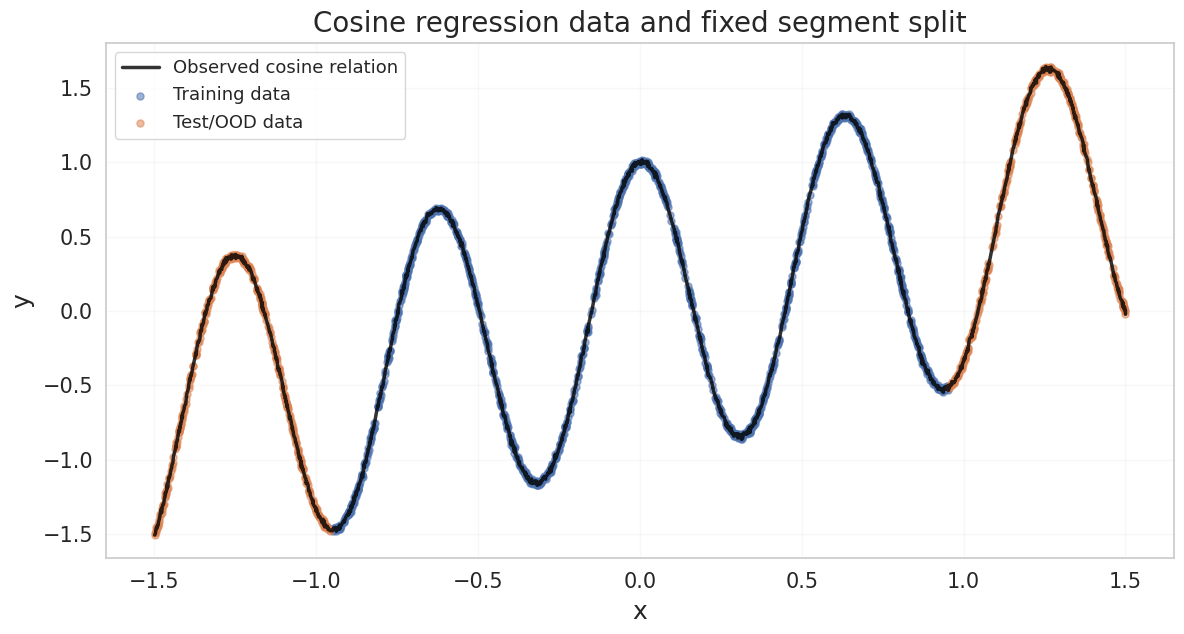

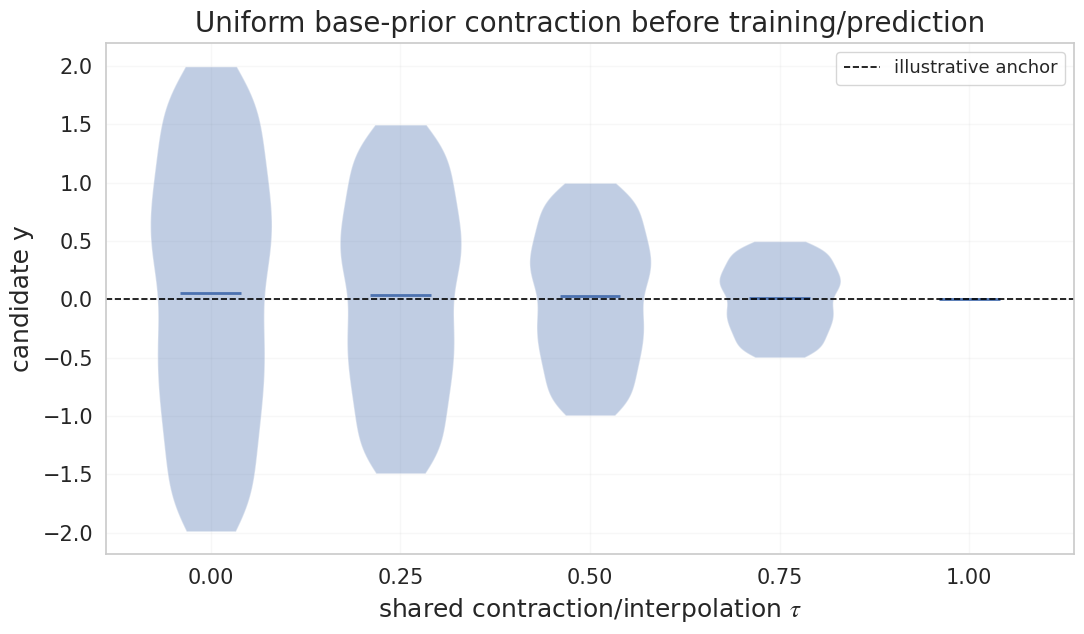

In [ ]:
validate_config(CFG)
out = Path(CFG.output_dir)
out.mkdir(parents=True, exist_ok=True)

X_train, Y_train, X_test, Y_test = gen_data(CFG)
scaling = make_scaling(X_train, Y_train, CFG)

print("\n--- data / experiment setup: before training ---")
print(f"Train samples: {len(X_train)} | Test/OOD samples: {len(X_test)}")
if CFG.likelihood_conditioning_mode == "direct":
    conditioning_detail = (
        f"{CFG.posterior_conditioning} (DIRECT SINGLE noisy x -> x_in -> SiLU -> x_out; "
        "no likelihood Transformer)"
    )
else:
    conditioning_detail = (
        f"{CFG.posterior_conditioning} (causal likelihood-prefix memory)"
        if CFG.posterior_conditioning == "cross_attention"
        else f"{CFG.posterior_conditioning} (final causal likelihood-prefix token)"
    )
print(f"Posterior conditioning: {conditioning_detail}")
TRAIN_WITH_GP_PRIORS = gp_priors_enabled_for_training(CFG)
EVALUATE_WITH_GP_PRIORS = gp_priors_enabled_for_evaluation(CFG)

if TRAIN_WITH_GP_PRIORS:
    print(
        f"FRESH TRAINING PRIORS = GP-derived {CFG.gp_prior_representation} using "
        f"the {CFG.gp_prior_hyperparameter_source.upper()} kernel hyperparameters."
    )
    if CFG.gp_prior_representation == "covariance_cloud":
        print(
            "GP covariance cloud: pointwise kernel-weighted Gaussian over training y | "
            f"train/eval particles={CFG.num_particles}/{CFG.eval_particles} | "
            "support-dependent widening | no Cholesky/function sampling/prior averaging."
        )
    else:
        print(
            f"Historical GP function-sample path: particle noise "
            f"N(0, {CFG.gp_prior_particle_noise_std:.4f}^2) around f(x)."
        )
        print(
            f"function bank={CFG.gp_prior_num_functions} | evaluation functions={CFG.gp_prior_eval_samples} | "
            f"plotted individually={CFG.gp_prior_plot_samples}"
        )
else:
    if CFG.base_prior_distribution == "uniform":
        print(
            f"BASE TRAINING PRIOR = U({scaling.prior_low:.3f}, {scaling.prior_high:.3f}) "
            f"| hard width={scaling.prior_high - scaling.prior_low:.3f} | center={scaling.y_center:.3f}"
        )
    else:
        print(
            f"BASE TRAINING PRIOR = N({CFG.gaussian_prior_mean:.3f}, {CFG.gaussian_prior_std:.3f}^2) | "
            f"inspection span=mean +/- {CFG.gaussian_prior_visual_z:.3f} sigma "
            f"= [{scaling.prior_low:.3f}, {scaling.prior_high:.3f}]"
        )
    print(
        "Shared-tau prior interpolation/contraction: "
        f"tau ~ U({CFG.prior_interpolation_tau_min:.3f}, {CFG.prior_interpolation_tau_max:.3f})"
    )

print(
    "GP evaluation priors: "
    + (
        f"ENABLED ({CFG.gp_prior_representation}, {CFG.gp_prior_hyperparameter_source} hyperparameters)"
        if EVALUATE_WITH_GP_PRIORS
        else f"DISABLED (legacy evaluation mode={CFG.evaluation_prior_mode})"
    )
)
print(
    f"Gaussian x-likelihood during training: x_lik ~ N(x_pair, {CFG.likelihood_x_noise_std:.4f}^2). "
    "Deployment/evaluation x is NOT noisified."
)
if CFG.likelihood_conditioning_mode == "transformer":
    print(
        "Likelihood observation prefixes: "
        f"train o={CFG.min_observations_per_step}..{CFG.max_observations_per_step} "
        f"(one independent noise draw per observation) | deployment o={CFG.test_observations_per_step}"
    )
    print(
        "Likelihood conditioning: causal Transformer | "
        f"hidden={CFG.likelihood_hidden_dim}, heads={CFG.likelihood_heads}, "
        f"depth={CFG.likelihood_depth}, mlp_ratio={CFG.likelihood_mlp_ratio}"
    )
else:
    print(
        "Likelihood conditioning: DIRECT SINGLE-OBSERVATION MODE | exactly one noisy x_lik per "
        "training example; x_lik -> x_in -> SiLU -> x_out inside the Bayes transporter; "
        "no likelihood Transformer and no prefixes. Deployment uses exactly one clean x."
    )
    print(
        "NOTE: min/max/test_observations_per_step are Transformer-only settings and are ignored "
        "in direct mode."
    )
print(
    "Configured evaluation prior mode: "
    + (f"gp_{CFG.gp_prior_representation}" if EVALUATE_WITH_GP_PRIORS else CFG.evaluation_prior_mode)
)
train_inside = np.mean((Y_train >= scaling.prior_low) & (Y_train <= scaling.prior_high))
test_inside = np.mean((Y_test >= scaling.prior_low) & (Y_test <= scaling.prior_high))
print(
    f"Train y: min={Y_train.min():.3f} max={Y_train.max():.3f} "
    f"mean={Y_train.mean():.3f} std={Y_train.std():.3f} | inside effective base-prior span={train_inside:.3%}"
)
print(
    f"Test  y: min={Y_test.min():.3f} max={Y_test.max():.3f} "
    f"mean={Y_test.mean():.3f} std={Y_test.std():.3f} | inside effective base-prior span={test_inside:.3%}"
)
print(
    f"truth_anchor_probability={CFG.truth_anchor_probability:.3f}"
    + (" (legacy fresh-prior setting; inactive)" if TRAIN_WITH_GP_PRIORS else "")
    + f" | historical_replay_probability={CFG.historical_output_prior_probability:.3f} | "
    f"train/eval particles={CFG.num_particles}/{CFG.eval_particles}"
)
if train_inside < 1.0 or test_inside < 1.0:
    print("NOTE: some observed y values lie outside the configured base-prior inspection span.")
plot_data_split(X_train, Y_train, X_test, Y_test, out / "data_split.pdf", CFG)
if not TRAIN_WITH_GP_PRIORS:
    # Historical fresh-prior diagnostic; the GP-function path gets its own prior-bank plot below
    # after the unfitted GP has been instantiated and sampled.
    plot_prior_interpolation_demo(out / "base_prior_contraction_demo.pdf", CFG)

In [ ]:
def sample_likelihood_x_np(
    rng: np.random.Generator,
    x_pair: np.ndarray,
    cfg: Config,
    *,
    num_observations: int | None = None,
) -> np.ndarray:
    """Draw independent x_lik observations for every supplied clean x_pair.

    Returns [B,O]. Observation j is one independent Gaussian noise sample around the same
    clean x_pair. This is the cosine analogue of one independent likelihood observation token.
    """
    x_pair = np.asarray(x_pair, dtype=np.float32).reshape(-1)
    o = cfg.max_observations_per_step if num_observations is None else int(num_observations)
    if o < 1:
        raise ValueError("num_observations must be >= 1.")
    noise = rng.normal(size=(len(x_pair), o)).astype(np.float32)
    return (
        x_pair[:, None] + np.float32(cfg.likelihood_x_noise_std) * noise
    ).astype(np.float32)


def gaussian_likelihood_logpdf_np(
    x_lik: np.ndarray,
    x_pair: np.ndarray,
    std: float,
) -> np.ndarray:
    """Log-density of the configured Gaussian empirical likelihood."""
    z = (np.asarray(x_lik) - np.asarray(x_pair)) / float(std)
    return -0.5 * z**2 - np.log(float(std) * np.sqrt(2.0 * np.pi))

In [ ]:
def _linear_tokens(layer: eqx.nn.Linear, x: Array) -> Array:
    return jax.vmap(layer)(x)


def _layernorm_tokens(layer: eqx.nn.LayerNorm, x: Array) -> Array:
    return jax.vmap(layer)(x)


def _modulate(x: Array, shift: Array, scale: Array) -> Array:
    return x * (1.0 + scale[None, :]) + shift[None, :]


class CausalObservationBlock(eqx.Module):
    """Transformer block over one Omax x-likelihood sequence with a causal mask."""
    norm1: eqx.nn.LayerNorm
    norm2: eqx.nn.LayerNorm
    attention: eqx.nn.MultiheadAttention
    ff_in: eqx.nn.Linear
    ff_out: eqx.nn.Linear

    def __init__(self, dim: int, heads: int, mlp_dim: int, *, key: Array):
        attn_key, ff1_key, ff2_key = jax.random.split(key, 3)
        self.norm1 = eqx.nn.LayerNorm(dim)
        self.norm2 = eqx.nn.LayerNorm(dim)
        self.attention = eqx.nn.MultiheadAttention(
            num_heads=heads, query_size=dim, key_size=dim, value_size=dim,
            output_size=dim, dropout_p=0.0, key=attn_key,
        )
        self.ff_in = eqx.nn.Linear(dim, mlp_dim, key=ff1_key)
        self.ff_out = eqx.nn.Linear(mlp_dim, dim, key=ff2_key)

    def __call__(self, tokens: Array) -> Array:
        length = tokens.shape[0]
        index = jnp.arange(length)
        causal_mask = index[:, None] >= index[None, :]
        h = _layernorm_tokens(self.norm1, tokens)
        tokens = tokens + self.attention(h, h, h, mask=causal_mask)
        h = _layernorm_tokens(self.norm2, tokens)
        h = jax.nn.gelu(_linear_tokens(self.ff_in, h))
        return tokens + _linear_tokens(self.ff_out, h)


class LikelihoodSequenceEmbedder(eqx.Module):
    """Project and causally contextualise noisy x observations in Transformer mode.

    Output token o can depend only on observations 0,...,o. One causal pass therefore provides
    all prefix contexts used on the training step. This module is NOT instantiated at all in
    ``direct`` mode; direct mode instead uses the historical single-x x_in -> SiLU -> x_out path.

    If Transformer mode itself is configured with Omin=Omax=1, the likelihood Transformer is
    automatically bypassed, matching the location-finding implementation's zero-parameter
    single-observation path.
    """
    input_projection: eqx.nn.Linear | None
    blocks: tuple[CausalObservationBlock, ...]
    final_norm: eqx.nn.LayerNorm | None
    input_dim: int = eqx.field(static=True)
    hidden_dim: int = eqx.field(static=True)
    attention_heads: int = eqx.field(static=True)
    bypass_transformer: bool = eqx.field(static=True)

    def __init__(self, cfg: Config, *, key: Array, input_dim: int = 1):
        self.input_dim = int(input_dim)
        single_observation = (
            cfg.min_observations_per_step == 1 and cfg.max_observations_per_step == 1
        )
        self.bypass_transformer = single_observation
        if self.bypass_transformer:
            self.hidden_dim = self.input_dim
            self.attention_heads = 0
            self.input_projection = None
            self.blocks = ()
            self.final_norm = None
            return

        self.hidden_dim = int(cfg.likelihood_hidden_dim)
        self.attention_heads = int(cfg.likelihood_heads)
        keys = jax.random.split(key, cfg.likelihood_depth + 1)
        self.input_projection = eqx.nn.Linear(self.input_dim, self.hidden_dim, key=keys[0])
        self.blocks = tuple(
            CausalObservationBlock(
                self.hidden_dim,
                self.attention_heads,
                cfg.likelihood_mlp_ratio * self.hidden_dim,
                key=keys[1 + i],
            )
            for i in range(cfg.likelihood_depth)
        )
        self.final_norm = eqx.nn.LayerNorm(self.hidden_dim)

    def __call__(self, observation_tokens: Array) -> Array:
        if self.bypass_transformer:
            return observation_tokens
        if self.input_projection is None or self.final_norm is None:
            raise RuntimeError("Active likelihood Transformer is missing its learned layers.")
        tokens = _linear_tokens(self.input_projection, observation_tokens)
        for block in self.blocks:
            tokens = block(tokens)
        return _layernorm_tokens(self.final_norm, tokens)


class AdaLNParticleBlock(eqx.Module):
    """Particle self-attention conditioned by the causal summary token for observations 1:o."""
    norm_attn: eqx.nn.LayerNorm
    norm_ff: eqx.nn.LayerNorm
    attention: eqx.nn.MultiheadAttention
    ff_in: eqx.nn.Linear
    ff_out: eqx.nn.Linear
    modulation: eqx.nn.Linear

    def __init__(
        self, hidden: int, conditioning_dim: int, heads: int, mlp_dim: int, *, key: Array
    ):
        k_attn, k_ff1, k_ff2, k_mod = jax.random.split(key, 4)
        self.norm_attn = eqx.nn.LayerNorm(hidden)
        self.norm_ff = eqx.nn.LayerNorm(hidden)
        self.attention = eqx.nn.MultiheadAttention(
            num_heads=heads, query_size=hidden, key_size=hidden, value_size=hidden,
            output_size=hidden, dropout_p=0.0, key=k_attn,
        )
        self.ff_in = eqx.nn.Linear(hidden, mlp_dim, key=k_ff1)
        self.ff_out = eqx.nn.Linear(mlp_dim, hidden, key=k_ff2)
        modulation = eqx.nn.Linear(conditioning_dim, 6 * hidden, key=k_mod)
        modulation = eqx.tree_at(lambda l: l.weight, modulation, jnp.zeros_like(modulation.weight))
        modulation = eqx.tree_at(lambda l: l.bias, modulation, jnp.zeros_like(modulation.bias))
        self.modulation = modulation

    def __call__(self, particles: Array, conditioning: Array) -> Array:
        shift_a, scale_a, gate_a, shift_f, scale_f, gate_f = jnp.split(
            self.modulation(jax.nn.silu(conditioning)), 6, axis=-1
        )
        h = _modulate(_layernorm_tokens(self.norm_attn, particles), shift_a, scale_a)
        particles = particles + gate_a[None, :] * self.attention(h, h, h)
        h = _modulate(_layernorm_tokens(self.norm_ff, particles), shift_f, scale_f)
        h = jax.nn.gelu(_linear_tokens(self.ff_in, h))
        return particles + gate_f[None, :] * _linear_tokens(self.ff_out, h)


class CrossAttentionParticleBlock(eqx.Module):
    """Particle self-attention followed by cross-attention to the active causal prefix."""
    norm_self: eqx.nn.LayerNorm
    norm_cross: eqx.nn.LayerNorm
    memory_norm: eqx.nn.LayerNorm
    norm_ff: eqx.nn.LayerNorm
    self_attention: eqx.nn.MultiheadAttention
    cross_attention: eqx.nn.MultiheadAttention
    ff_in: eqx.nn.Linear
    ff_out: eqx.nn.Linear

    def __init__(
        self, hidden: int, memory_dim: int, heads: int, mlp_dim: int, *, key: Array
    ):
        k_self, k_cross, k_ff1, k_ff2 = jax.random.split(key, 4)
        self.norm_self = eqx.nn.LayerNorm(hidden)
        self.norm_cross = eqx.nn.LayerNorm(hidden)
        self.memory_norm = eqx.nn.LayerNorm(memory_dim)
        self.norm_ff = eqx.nn.LayerNorm(hidden)
        self.self_attention = eqx.nn.MultiheadAttention(
            num_heads=heads, query_size=hidden, key_size=hidden, value_size=hidden,
            output_size=hidden, dropout_p=0.0, key=k_self,
        )
        self.cross_attention = eqx.nn.MultiheadAttention(
            num_heads=heads, query_size=hidden, key_size=memory_dim, value_size=memory_dim,
            output_size=hidden, dropout_p=0.0, key=k_cross,
        )
        self.ff_in = eqx.nn.Linear(hidden, mlp_dim, key=k_ff1)
        self.ff_out = eqx.nn.Linear(mlp_dim, hidden, key=k_ff2)

    def __call__(self, particles: Array, observation_memory: Array) -> Array:
        h = _layernorm_tokens(self.norm_self, particles)
        particles = particles + self.self_attention(h, h, h)
        q = _layernorm_tokens(self.norm_cross, particles)
        memory = _layernorm_tokens(self.memory_norm, observation_memory)
        particles = particles + self.cross_attention(q, memory, memory)
        h = _layernorm_tokens(self.norm_ff, particles)
        h = jax.nn.gelu(_linear_tokens(self.ff_in, h))
        return particles + _linear_tokens(self.ff_out, h)


class ConditionalParticleTransport(eqx.Module):
    """One prior->posterior map with either Transformer or direct single-x conditioning.

    ``transformer`` mode is the multi-observation likelihood-Transformer architecture.
    ``direct`` mode deliberately reproduces the attached historical cosine implementation:
    exactly one scalar noisy x is mapped by x_in -> SiLU -> x_out and supplied directly to
    the particle blocks. Direct mode has no likelihood Transformer and no observation prefix.
    """
    particle_in: eqx.nn.Linear
    likelihood_embedder: LikelihoodSequenceEmbedder | None
    x_in: eqx.nn.Linear | None
    x_out: eqx.nn.Linear | None
    blocks: tuple[Any, ...]
    final_norm: eqx.nn.LayerNorm
    displacement_head: eqx.nn.Linear

    x_center: float = eqx.field(static=True)
    x_scale: float = eqx.field(static=True)
    y_center: float = eqx.field(static=True)
    y_scale: float = eqx.field(static=True)
    max_displacement: float = eqx.field(static=True)
    conditioning_type: str = eqx.field(static=True)
    likelihood_conditioning_mode: str = eqx.field(static=True)
    min_observations: int = eqx.field(static=True)
    max_observations: int = eqx.field(static=True)
    observation_context_dim: int = eqx.field(static=True)

    def __init__(self, cfg: Config, scaling: Scaling, *, key: Array):
        h = cfg.hidden_dim
        self.likelihood_conditioning_mode = cfg.likelihood_conditioning_mode

        if cfg.likelihood_conditioning_mode == "direct":
            # EXACT architecture of the attached single-observation cosine transport:
            # particle_in plus x_in -> SiLU -> x_out, then AdaLN or cross-attention blocks.
            keys = jax.random.split(key, cfg.posterior_depth + 5)
            self.likelihood_embedder = None
            self.particle_in = eqx.nn.Linear(1, h, key=keys[0])
            self.x_in = eqx.nn.Linear(1, h, key=keys[1])
            x_out_dim = h if cfg.posterior_conditioning == "adaln" else h * cfg.cross_attention_tokens
            self.x_out = eqx.nn.Linear(h, x_out_dim, key=keys[2])
            self.observation_context_dim = h
            block_cls = AdaLNParticleBlock if cfg.posterior_conditioning == "adaln" else CrossAttentionParticleBlock
            self.blocks = tuple(
                block_cls(
                    h,
                    h,
                    cfg.heads,
                    cfg.mlp_ratio * h,
                    key=keys[3 + i],
                )
                for i in range(cfg.posterior_depth)
            )
            self.final_norm = eqx.nn.LayerNorm(h)
            head = eqx.nn.Linear(h, 1, key=keys[-2])
        else:
            # Preserve the existing multi-observation likelihood-Transformer path unchanged.
            keys = jax.random.split(key, cfg.posterior_depth + 4)
            self.likelihood_embedder = LikelihoodSequenceEmbedder(cfg, input_dim=1, key=keys[0])
            self.x_in = None
            self.x_out = None
            self.observation_context_dim = self.likelihood_embedder.hidden_dim
            self.particle_in = eqx.nn.Linear(1, h, key=keys[1])
            block_cls = AdaLNParticleBlock if cfg.posterior_conditioning == "adaln" else CrossAttentionParticleBlock
            self.blocks = tuple(
                block_cls(
                    h,
                    self.observation_context_dim,
                    cfg.heads,
                    cfg.mlp_ratio * h,
                    key=keys[2 + i],
                )
                for i in range(cfg.posterior_depth)
            )
            self.final_norm = eqx.nn.LayerNorm(h)
            head = eqx.nn.Linear(h, 1, key=keys[-1])

        head = eqx.tree_at(lambda l: l.weight, head, jnp.zeros_like(head.weight))
        head = eqx.tree_at(lambda l: l.bias, head, jnp.zeros_like(head.bias))
        self.displacement_head = head
        self.x_center, self.x_scale = scaling.x_center, scaling.x_scale
        self.y_center, self.y_scale = scaling.y_center, scaling.y_scale
        self.max_displacement = cfg.max_normalized_displacement
        self.conditioning_type = cfg.posterior_conditioning
        self.min_observations = int(cfg.min_observations_per_step)
        self.max_observations = int(cfg.max_observations_per_step)

    def direct_transport(self, prior_y: Array, x: Array) -> Array:
        """Historical direct cosine path: prior_y [N], ONE x scalar -> posterior_y [N]."""
        if self.likelihood_conditioning_mode != "direct":
            raise RuntimeError("direct_transport is available only in direct likelihood mode.")
        if self.x_in is None or self.x_out is None:
            raise RuntimeError("Direct mode is missing x_in/x_out projections.")

        yn = (prior_y - self.y_center) / self.y_scale
        xn = (jnp.reshape(x, (1,)) - self.x_center) / self.x_scale
        particles = _linear_tokens(self.particle_in, yn[:, None])
        conditioning = self.x_out(jax.nn.silu(self.x_in(xn)))
        if self.conditioning_type == "cross_attention":
            conditioning = conditioning.reshape(-1, particles.shape[-1])
        for block in self.blocks:
            particles = block(particles, conditioning)
        particles = _layernorm_tokens(self.final_norm, particles)
        delta = self.max_displacement * jnp.tanh(
            _linear_tokens(self.displacement_head, particles)[:, 0]
        )
        return self.y_center + self.y_scale * (yn + delta)

    def encode_observations(self, x_observations: Array) -> Array:
        """Transformer mode only: x_observations [O] -> causal contexts [O,C]."""
        if self.likelihood_conditioning_mode != "transformer" or self.likelihood_embedder is None:
            raise RuntimeError("encode_observations is only used in likelihood Transformer mode.")
        xn = (x_observations - self.x_center) / self.x_scale
        return self.likelihood_embedder(xn[:, None])

    def transport_with_contexts(
        self, prior_y: Array, observation_contexts: Array, observation_count: Array
    ) -> Array:
        """Transformer mode only: direct prior -> posterior for one selected prefix."""
        if self.likelihood_conditioning_mode != "transformer":
            raise RuntimeError("Observation prefixes are not used in direct single-observation mode.")
        yn = (prior_y - self.y_center) / self.y_scale
        count = jnp.clip(observation_count, 1, observation_contexts.shape[0]).astype(jnp.int32)

        if self.conditioning_type == "cross_attention":
            def branch_for(prefix_length: int):
                def transport(args):
                    yn_local, full_memory = args
                    particles = _linear_tokens(self.particle_in, yn_local[:, None])
                    memory = full_memory[:prefix_length]
                    for block in self.blocks:
                        particles = block(particles, memory)
                    return particles
                return transport

            branches = tuple(
                branch_for(prefix_length)
                for prefix_length in range(1, observation_contexts.shape[0] + 1)
            )
            particles = jax.lax.switch(count - 1, branches, (yn, observation_contexts))
        else:
            # Causal Transformer token o-1 summarizes exactly observations 1:o.
            conditioning = observation_contexts[count - 1]
            particles = _linear_tokens(self.particle_in, yn[:, None])
            for block in self.blocks:
                particles = block(particles, conditioning)

        particles = _layernorm_tokens(self.final_norm, particles)
        delta = self.max_displacement * jnp.tanh(
            _linear_tokens(self.displacement_head, particles)[:, 0]
        )
        return self.y_center + self.y_scale * (yn + delta)

    def predict_prefixes(self, prior_y: Array, x_observations: Array) -> tuple[Array, Array]:
        """Transformer mode: posterior for EVERY configured prefix from the SAME prior cloud."""
        if self.likelihood_conditioning_mode != "transformer":
            raise RuntimeError(
                "predict_prefixes is Transformer-only. Direct mode uses exactly one x observation."
            )
        contexts = self.encode_observations(x_observations)
        prefix_counts = jnp.arange(self.min_observations, self.max_observations + 1, dtype=jnp.int32)
        # Serialize only the tiny observation-prefix axis instead of vmapping it.
        # This preserves the Mac/XLA compatibility fix from the previous revision.
        posterior_by_prefix = jax.lax.map(
            lambda count: self.transport_with_contexts(prior_y, contexts, count),
            prefix_counts,
        )
        return posterior_by_prefix, prefix_counts

    def __call__(self, prior_y: Array, x_observations: Array, observation_count: Array) -> Array:
        """Evaluate the configured likelihood path.

        Direct mode requires x_observations.shape == [1] and observation_count == 1.
        Transformer mode accepts any trained prefix length.
        """
        if self.likelihood_conditioning_mode == "direct":
            # Main direct training/evaluation paths call direct_transport with a scalar. This branch
            # is retained only as a convenience for callers that provide a length-one array.
            x_flat = jnp.reshape(x_observations, (-1,))
            if x_flat.shape[0] != 1:
                raise ValueError("Direct likelihood mode requires exactly ONE x observation.")
            return self.direct_transport(prior_y, x_flat[0])
        contexts = self.encode_observations(x_observations)
        return self.transport_with_contexts(prior_y, contexts, observation_count)

In [ ]:
def empirical_energy_score_terms(posterior: Array, target: Array) -> tuple[Array, Array, Array]:
    """1-D empirical ES: E|Y-y*| - 1/2 E|Y-Y'|."""
    attraction = jnp.mean(jnp.abs(posterior - target))
    repulsion = jnp.mean(jnp.abs(posterior[:, None] - posterior[None, :]))
    return attraction - 0.5 * repulsion, attraction, repulsion


def prefix_batch_metrics(
    posterior_by_prefix: Array, target: Array, prefix_counts: Array, cfg: Config = CFG
) -> dict[str, Array]:
    """Metrics for [B,P,N] posterior clouds; scalar loss averages all rows and prefixes."""
    mean = jnp.mean(posterior_by_prefix, axis=-1)  # [B,P]
    lo = jnp.quantile(posterior_by_prefix, cfg.interval_low_q, axis=-1)
    hi = jnp.quantile(posterior_by_prefix, cfg.interval_high_q, axis=-1)

    def row_terms(prefix_clouds, yi):
        return jax.vmap(lambda cloud: empirical_energy_score_terms(cloud, yi))(prefix_clouds)

    score, attraction, repulsion = jax.vmap(row_terms)(posterior_by_prefix, target)
    mse = (mean - target[:, None]) ** 2
    coverage = (target[:, None] >= lo) & (target[:, None] <= hi)
    width = hi - lo
    spread = jnp.std(posterior_by_prefix, axis=-1)
    return {
        "loss": jnp.mean(score),
        "energy_score": jnp.mean(score),
        "final_energy_score": jnp.mean(score[:, -1]),
        "attraction": jnp.mean(attraction),
        "repulsion": jnp.mean(repulsion),
        "mean_mse": jnp.mean(mse),
        "final_mean_mse": jnp.mean(mse[:, -1]),
        "coverage_95": jnp.mean(coverage),
        "final_coverage_95": jnp.mean(coverage[:, -1]),
        "interval_width": jnp.mean(width),
        "posterior_std": jnp.mean(spread),
        "energy_by_o": jnp.mean(score, axis=0),
        "mse_by_o": jnp.mean(mse, axis=0),
        "coverage_by_o": jnp.mean(coverage, axis=0),
        "prefix_counts": prefix_counts,
    }


@dataclass(frozen=True)
class GPCovariancePriorCloud:
    """Pointwise Gaussian prior clouds derived from GP-kernel weighting of training outputs.

    For each query x*, non-negative normalized GP-kernel similarities to the training inputs are
    used as weights. The weighted training-y mean gives the Gaussian centre. The weighted local
    variance gives its in-support covariance, while absolute kernel support blends that variance
    toward the global training-y variance away from observed x. Training moments use leave-one-out
    weighting so a row's own target is never copied directly into its input prior cloud.
    """
    train_cloud: np.ndarray       # [N_train, num_particles]
    train_eval_cloud: np.ndarray  # [N_train, eval_particles]
    test_eval_cloud: np.ndarray   # [N_test, eval_particles]
    train_mean: np.ndarray
    test_mean: np.ndarray
    train_std: np.ndarray
    test_std: np.ndarray
    train_support: np.ndarray
    test_support: np.ndarray


def _gp_radial_similarity(kernel, x_query: np.ndarray, x_train: np.ndarray) -> np.ndarray:
    """Use the RBF component of the configured GP kernel as a pure closeness weight.

    The baseline kernel also contains linear and white-noise terms. Those are valid covariance
    components for GP regression, but they are not distance weights: a DotProduct term can assign
    large covariance to far-away points. For this local empirical prior we therefore reuse the
    configured/fitted RBF component, whose value is exactly a radial similarity in [0,1]. If a
    future kernel contains no RBF component, fall back to a normalized non-negative covariance.
    """
    xq2 = np.asarray(x_query, dtype=np.float64).reshape(-1, 1)
    xt2 = np.asarray(x_train, dtype=np.float64).reshape(-1, 1)

    def find_rbf(k):
        if isinstance(k, RBF):
            return k
        for name in ("k1", "k2"):
            child = getattr(k, name, None)
            if child is not None:
                found = find_rbf(child)
                if found is not None:
                    return found
        return None

    radial = find_rbf(kernel)
    if radial is not None:
        return np.clip(np.asarray(radial(xq2, xt2), dtype=np.float64), 0.0, 1.0)

    eps = np.finfo(np.float64).eps
    covariance = np.asarray(kernel(xq2, xt2), dtype=np.float64)
    qdiag = np.maximum(np.asarray(kernel.diag(xq2), dtype=np.float64), eps)
    tdiag = np.maximum(np.asarray(kernel.diag(xt2), dtype=np.float64), eps)
    similarity = covariance / np.sqrt(qdiag[:, None] * tdiag[None, :])
    return np.clip(similarity, 0.0, 1.0)


def _gp_kernel_weighted_moments(
    kernel,
    x_query: np.ndarray,
    x_train: np.ndarray,
    y_train: np.ndarray,
    *,
    leave_one_out: bool = False,
    variance_floor: float = 0.0,
    eps: float = 1e-12,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return radial-kernel-weighted mean, std, and absolute support for each query point.

    Normalized RBF similarities compute the local y moments. Their maximum before normalization is
    retained as an absolute support score in [0,1], so distance from observed x is not lost when the
    weights are normalized. That support score widens the variance toward the global training-y
    variance as the query moves away from the training set.
    """
    xq = np.asarray(x_query, dtype=np.float64).reshape(-1)
    xt = np.asarray(x_train, dtype=np.float64).reshape(-1)
    yt = np.asarray(y_train, dtype=np.float64).reshape(-1)
    if len(xt) != len(yt) or len(xt) == 0:
        raise ValueError("x_train and y_train must be non-empty and have the same length.")
    if leave_one_out and len(xq) != len(xt):
        raise ValueError("leave_one_out=True requires x_query and x_train to have the same length.")

    weights = _gp_radial_similarity(kernel, xq, xt)

    if leave_one_out:
        # Preserve the existing strict-supervised behaviour: the current row's y* must not be
        # injected into its own prior cloud. Other nearby training observations remain available.
        weights[np.arange(len(xt)), np.arange(len(xt))] = 0.0

    support = np.max(weights, axis=1)
    weight_sum = np.sum(weights, axis=1)
    dead = weight_sum <= eps
    normalized = weights / np.maximum(weight_sum[:, None], eps)

    mean = normalized @ yt
    local_var = np.sum(normalized * (yt[None, :] - mean[:, None]) ** 2, axis=1)
    global_mean = float(np.mean(yt))
    global_var = max(float(np.var(yt)), float(variance_floor), eps)

    if np.any(dead):
        # At numerical zero support, no weighted local estimate exists. Revert to the empirical
        # training-output moments; support=0 then selects the global variance exactly.
        mean[dead] = global_mean
        local_var[dead] = global_var
        support[dead] = 0.0

    # Local disagreement determines the supported width. Far from data, support -> 0 and the prior
    # smoothly widens to the global training-y variance. Capping local variance by global variance
    # enforces the intended qualitative rule that stronger training support cannot make the prior
    # wider than the unsupported fallback cloud.
    local_var = np.clip(local_var, float(variance_floor), global_var)
    variance = support * local_var + (1.0 - support) * global_var
    std = np.sqrt(np.maximum(variance, float(variance_floor)))
    return mean.astype(np.float32), std.astype(np.float32), support.astype(np.float32)


def _sample_pointwise_gaussian_cloud(
    rng: np.random.Generator,
    mean: np.ndarray,
    std: np.ndarray,
    num_particles: int,
) -> np.ndarray:
    """Sample independent scalar Gaussian particles at each query point."""
    mean = np.asarray(mean, dtype=np.float64).reshape(-1)
    std = np.asarray(std, dtype=np.float64).reshape(-1)
    if mean.shape != std.shape:
        raise ValueError("mean and std must have the same shape.")
    return rng.normal(
        loc=mean[:, None],
        scale=std[:, None],
        size=(len(mean), int(num_particles)),
    ).astype(np.float32)


def build_gp_covariance_prior_cloud(
    gp_prior_sampler: GaussianProcessRegressor,
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_test: np.ndarray,
    cfg: Config,
) -> GPCovariancePriorCloud:
    """Build simple kernel-weighted Gaussian transport priors at train and test inputs.

    Only the GP kernel hyperparameters are reused. No GP posterior is formed and no covariance
    matrix is factorised. At x*, the kernel similarities to observed x_train are positive weights
    for the training outputs: mu(x*) is their weighted average. The weighted y variance is the local
    covariance estimate, and absolute kernel support widens it toward the global y variance as x*
    leaves the training set. The resulting N(mu, var) is sampled directly into transport particles.
    """
    if hasattr(gp_prior_sampler, "X_train_"):
        raise ValueError("GP prior sampler must remain unfitted; only its kernel weights are used.")
    x_train = np.asarray(x_train, dtype=np.float64).reshape(-1)
    y_train = np.asarray(y_train, dtype=np.float64).reshape(-1)
    x_test = np.asarray(x_test, dtype=np.float64).reshape(-1)
    variance_floor = max(float(cfg.noise_std) ** 2, np.finfo(np.float64).eps)

    train_mean, train_std, train_support = _gp_kernel_weighted_moments(
        gp_prior_sampler.kernel,
        x_train,
        x_train,
        y_train,
        leave_one_out=True,
        variance_floor=variance_floor,
    )
    test_mean, test_std, test_support = _gp_kernel_weighted_moments(
        gp_prior_sampler.kernel,
        x_test,
        x_train,
        y_train,
        leave_one_out=False,
        variance_floor=variance_floor,
    )

    train_rng = np.random.default_rng(cfg.seed + 41_001)
    train_eval_rng = np.random.default_rng(cfg.seed + 41_002)
    test_eval_rng = np.random.default_rng(cfg.seed + 41_003)
    return GPCovariancePriorCloud(
        train_cloud=_sample_pointwise_gaussian_cloud(
            train_rng, train_mean, train_std, cfg.num_particles
        ),
        train_eval_cloud=_sample_pointwise_gaussian_cloud(
            train_eval_rng, train_mean, train_std, cfg.eval_particles
        ),
        test_eval_cloud=_sample_pointwise_gaussian_cloud(
            test_eval_rng, test_mean, test_std, cfg.eval_particles
        ),
        train_mean=train_mean,
        test_mean=test_mean,
        train_std=train_std,
        test_std=test_std,
        train_support=train_support,
        test_support=test_support,
    )

def sample_gp_function_particle_prior_np(
    rng: np.random.Generator,
    function_mean: np.ndarray,
    n_particles: int,
    cfg: Config,
) -> np.ndarray:
    """Draw transport particles around one sampled GP function evaluated at the requested x values.

    ``function_mean[i]`` is f(x_i) from one coherent draw of the fresh UNFITTED GP prior sampler.
    That sampler carries either the configured initial kernel hyperparameters or the fitted kernel_
    hyperparameters, according to ``gp_prior_hyperparameter_source``. Conditional on the function
    draw, the particle cloud is Gaussian with configurable standard deviation. The extra particle
    noise is a transport-prior width, not a refit or modification of the GP kernel.
    """
    center = np.asarray(function_mean, dtype=np.float32).reshape(-1)
    noise = rng.normal(
        0.0,
        float(cfg.gp_prior_particle_noise_std),
        size=(len(center), int(n_particles)),
    ).astype(np.float32)
    return (center[:, None] + noise).astype(np.float32)


def sample_interpolated_prior_np(
    rng: np.random.Generator,
    target_y: np.ndarray,
    cfg: Config,
    scaling: Scaling,
) -> np.ndarray:
    """Legacy shared-tau contraction/interpolation for either Uniform or Gaussian base particles.

    This path is retained unchanged for reproducibility and is used when
    GP priors are disabled for training.

    C_tau=(1-tau)Z+tau*anchor uses one shared tau per cloud. For Gaussian Z and a fixed anchor,
    the resulting cloud is still Gaussian with std (1-tau)*sigma, so contraction is exact.
    No synthetic (x,y) pairs are created.
    """
    b = len(target_y)
    z = sample_base_prior_np(rng, (b, cfg.num_particles), cfg, scaling)
    independent_anchor = sample_base_prior_np(rng, (b,), cfg, scaling)
    use_truth = rng.random(b) < cfg.truth_anchor_probability
    anchor = np.where(use_truth, target_y, independent_anchor).astype(np.float32)
    tau = rng.uniform(
        float(cfg.prior_interpolation_tau_min),
        float(cfg.prior_interpolation_tau_max),
        size=(b, 1),
    ).astype(np.float32)
    return ((1.0 - tau) * z + tau * anchor[:, None]).astype(np.float32)


class HistoricalOutputPriorBuffer:
    """Fixed-size NumPy nearest-posterior prior buffer.

    Each slot stores only:
      * the clean training coordinate x_pair;
      * the detached posterior y cloud previously achieved there.

    During training, replay means "use the posterior achieved at the closest stored x as the
    CURRENT row's prior". It deliberately does NOT replay the stored target or likelihood evidence.
    This makes nearby achieved posteriors part of the learned prior-crafting distribution.
    """
    def __init__(self, capacity: int, num_particles: int):
        self.capacity = int(capacity)
        self.num_particles = int(num_particles)
        if self.capacity < 1:
            raise ValueError("Historical-output buffer capacity must be >= 1.")
        if self.num_particles < 2:
            raise ValueError("Historical-output buffer requires at least two particles.")
        self.x = np.empty(self.capacity, dtype=np.float32)
        self.clouds = np.empty((self.capacity, self.num_particles), dtype=np.float32)
        self.size = 0
        self.next_index = 0

    def __len__(self) -> int:
        return int(self.size)

    @property
    def active_x(self) -> np.ndarray:
        return self.x[:self.size]

    @property
    def active_clouds(self) -> np.ndarray:
        return self.clouds[:self.size]

    def add_batch(self, posterior: np.ndarray, x_pair: np.ndarray) -> None:
        """Insert detached (x, posterior-cloud) pairs into the ring buffer."""
        posterior = np.asarray(posterior, dtype=np.float32)
        x_pair = np.asarray(x_pair, dtype=np.float32).reshape(-1)
        if posterior.ndim != 2 or posterior.shape[0] != len(x_pair):
            raise ValueError("posterior must have shape [B,N] with one x_pair per row.")
        if posterior.shape[1] != self.num_particles:
            raise ValueError(
                f"Buffer expects {self.num_particles} particles, got {posterior.shape[1]}."
            )
        for xc, cloud in zip(x_pair, posterior):
            self.x[self.next_index] = xc
            self.clouds[self.next_index] = cloud
            self.next_index = (self.next_index + 1) % self.capacity
            self.size = min(self.size + 1, self.capacity)

    def nearest_clouds(
        self,
        x_query: np.ndarray,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Return closest stored cloud, its stored x, and |x_query-x_stored| for every query."""
        if self.size == 0:
            raise ValueError("Nearest-posterior replay buffer is empty.")
        xq = np.asarray(x_query, dtype=np.float32).reshape(-1)
        distances = np.abs(xq[:, None] - self.active_x[None, :])
        nearest = np.argmin(distances, axis=1)
        rows = np.arange(len(xq))
        return (
            self.active_clouds[nearest].copy(),
            self.active_x[nearest].copy(),
            distances[rows, nearest].astype(np.float32),
        )

    def mix_into_batch(
        self,
        prior: np.ndarray,
        x_pair: np.ndarray,
        x_lik: np.ndarray,
        y: np.ndarray,
        rng: np.random.Generator,
        cfg: Config,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int]:
        """Occasionally replace ONLY the hand-designed prior by the nearest achieved posterior."""
        if self.size == 0 or cfg.historical_output_prior_probability <= 0.0:
            return prior, x_pair, x_lik, y, 0

        prior = np.asarray(prior, dtype=np.float32).copy()
        x_pair = np.asarray(x_pair, dtype=np.float32)
        selected = np.flatnonzero(
            rng.random(len(x_pair)) < cfg.historical_output_prior_probability
        )
        if len(selected):
            replay_clouds, _, _ = self.nearest_clouds(x_pair[selected])
            prior[selected] = replay_clouds

        # x_pair, x_lik, and y deliberately remain the CURRENT row's evidence and target.
        return prior, x_pair, x_lik, y, int(len(selected))

    def resampled_copy(
        self,
        num_particles: int,
        rng: np.random.Generator,
    ) -> "HistoricalOutputPriorBuffer":
        """Copy the active buffer, bootstrap-resampling clouds if the particle count changes."""
        if self.size == 0:
            raise ValueError("Cannot copy an empty nearest-posterior replay buffer.")
        num_particles = int(num_particles)
        copied = HistoricalOutputPriorBuffer(self.capacity, num_particles)
        source = self.active_clouds
        if num_particles == self.num_particles:
            clouds = source.copy()
        else:
            ids = rng.integers(0, self.num_particles, size=(self.size, num_particles))
            clouds = np.take_along_axis(source, ids, axis=1).astype(np.float32)
        copied.add_batch(clouds, self.active_x)
        return copied

In [ ]:
def _transport_objective(
    model: ConditionalParticleTransport,
    prior: Array,
    x_observations: Array,
    y: Array,
    cfg: Config,
) -> tuple[Array, tuple[dict[str, Array], Array]]:
    """Train the selected likelihood path.

    Transformer mode optimizes every configured prefix. Direct mode deliberately has exactly
    ONE noisy x observation and therefore exactly one posterior per training row.
    """
    if cfg.likelihood_conditioning_mode == "direct":
        # x_observations is [B] here: exactly one scalar noisy x_lik per training example.
        posterior = jax.vmap(model.direct_transport)(prior, x_observations)
        posterior_by_prefix = posterior[:, None, :]  # [B,1,N], only to reuse metric bookkeeping.
        prefix_counts = jnp.asarray([1], dtype=jnp.int32)
    else:
        posterior_by_prefix, prefix_counts = jax.vmap(
            lambda p, obs: model.predict_prefixes(p, obs)
        )(prior, x_observations)

    metrics = prefix_batch_metrics(posterior_by_prefix, y, prefix_counts, cfg)
    return metrics["loss"], (metrics, posterior_by_prefix[:, -1])


_loss_and_grad = eqx.filter_value_and_grad(_transport_objective, has_aux=True)


def make_train_step(optimizer: optax.GradientTransformation, cfg: Config):
    @eqx.filter_jit
    def step(model, opt_state, prior, x_observations, y):
        (loss, (metrics, final_posterior)), grads = _loss_and_grad(
            model, prior, x_observations, y, cfg
        )
        params = eqx.filter(model, eqx.is_array)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        model = eqx.apply_updates(model, updates)
        grad_norm = optax.global_norm(eqx.filter(grads, eqx.is_array))
        return model, opt_state, loss, metrics, final_posterior, grad_norm
    return step


def train_transport(
    x_train: np.ndarray,
    y_train: np.ndarray,
    scaling: Scaling,
    cfg: Config = CFG,
    *,
    model: ConditionalParticleTransport | None = None,
    gp_prior_train_values: np.ndarray | None = None,
    gp_prior_train_cloud: np.ndarray | None = None,
) -> tuple[ConditionalParticleTransport, dict[str, list[float]], HistoricalOutputPriorBuffer]:
    if model is None:
        model = ConditionalParticleTransport(cfg, scaling, key=jax.random.key(cfg.seed))
    optimizer = optax.chain(
        optax.clip_by_global_norm(cfg.grad_clip_norm),
        optax.adamw(cfg.learning_rate, weight_decay=cfg.weight_decay),
    )
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))
    train_step = make_train_step(optimizer, cfg)
    rng = np.random.default_rng(cfg.seed + 10_001)
    replay_rng = np.random.default_rng(cfg.seed + 20_003)
    replay = HistoricalOutputPriorBuffer(
        cfg.historical_output_buffer_capacity, cfg.num_particles
    )
    if gp_priors_enabled_for_training(cfg):
        if cfg.gp_prior_representation == "covariance_cloud":
            if gp_prior_train_cloud is None:
                raise ValueError(
                    "gp_prior_representation='covariance_cloud' requires gp_prior_train_cloud."
                )
            gp_prior_train_cloud = np.asarray(gp_prior_train_cloud, dtype=np.float32)
            if gp_prior_train_cloud.shape != (len(x_train), cfg.num_particles):
                raise ValueError(
                    "gp_prior_train_cloud must have shape [len(x_train), cfg.num_particles]."
                )
        else:
            if gp_prior_train_values is None:
                raise ValueError(
                    "gp_prior_representation='function_samples' requires gp_prior_train_values."
                )
            gp_prior_train_values = np.asarray(gp_prior_train_values, dtype=np.float32)
            if gp_prior_train_values.ndim != 2 or gp_prior_train_values.shape[1] != len(x_train):
                raise ValueError(
                    "gp_prior_train_values must have shape [num_functions, len(x_train)]."
                )
    history = {name: [] for name in (
        "step", "energy_score", "final_energy_score", "attraction", "repulsion",
        "mean_mse", "final_mean_mse", "coverage_95", "final_coverage_95",
        "interval_width", "posterior_std", "grad_norm", "replay_fraction", "buffer_size",
        "likelihood_noise_rms", "likelihood_mean_logpdf"
    )}

    for step in range(1, cfg.epochs + 1):
        ids = rng.integers(0, len(x_train), size=cfg.batch_size)
        x_pair = x_train[ids].astype(np.float32)
        yb = y_train[ids].astype(np.float32)
        if gp_priors_enabled_for_training(cfg):
            if cfg.gp_prior_representation == "covariance_cloud":
                # ONE precomputed kernel-weighted Gaussian cloud: no function draw or extra output noisification.
                prior = gp_prior_train_cloud[ids].copy()
            else:
                # Historical v2 path: one sampled GP function for this step, then noisy particles.
                function_id = int(rng.integers(0, gp_prior_train_values.shape[0]))
                function_mean = gp_prior_train_values[function_id, ids]
                prior = sample_gp_function_particle_prior_np(
                    rng, function_mean, cfg.num_particles, cfg
                )
        else:
            # Exact historical fresh-prior path retained as an opt-out/reproducibility mode.
            prior = sample_interpolated_prior_np(rng, yb, cfg, scaling)
        # DIRECT mode exactly matches the attached historical cosine path: ONE noisy x_lik.
        # Transformer mode retains the configurable Omax independent likelihood observations.
        if cfg.likelihood_conditioning_mode == "direct":
            # Match the attached direct cosine code exactly at the evidence interface: [B] scalars.
            x_lik = sample_likelihood_x_np(
                rng, x_pair, cfg, num_observations=1
            )[:, 0]
        else:
            x_lik = sample_likelihood_x_np(
                rng, x_pair, cfg, num_observations=cfg.max_observations_per_step
            )
        prior, x_pair, x_lik, yb, n_replay = replay.mix_into_batch(
            prior, x_pair, x_lik, yb, replay_rng, cfg
        )
        model, opt_state, loss, metrics, final_posterior, grad_norm = train_step(
            model, opt_state, jnp.asarray(prior), jnp.asarray(x_lik), jnp.asarray(yb)
        )
        replay.add_batch(
            np.asarray(jax.device_get(final_posterior)), x_pair
        )

        if cfg.likelihood_conditioning_mode == "direct":
            likelihood_noise = np.asarray(x_lik) - np.asarray(x_pair)
            likelihood_logpdf = gaussian_likelihood_logpdf_np(
                x_lik, x_pair, cfg.likelihood_x_noise_std
            )
        else:
            likelihood_noise = np.asarray(x_lik) - np.asarray(x_pair)[:, None]
            likelihood_logpdf = gaussian_likelihood_logpdf_np(
                x_lik, np.asarray(x_pair)[:, None], cfg.likelihood_x_noise_std
            )

        # Collect EVERY optimizer step for dense training diagnostics. Printing can stay sparse.
        host = jax.device_get(metrics)
        values = {
            "step": float(step),
            "energy_score": float(host["energy_score"]),
            "final_energy_score": float(host["final_energy_score"]),
            "attraction": float(host["attraction"]),
            "repulsion": float(host["repulsion"]),
            "mean_mse": float(host["mean_mse"]),
            "final_mean_mse": float(host["final_mean_mse"]),
            "coverage_95": float(host["coverage_95"]),
            "final_coverage_95": float(host["final_coverage_95"]),
            "interval_width": float(host["interval_width"]),
            "posterior_std": float(host["posterior_std"]),
            "grad_norm": float(jax.device_get(grad_norm)),
            "replay_fraction": n_replay / cfg.batch_size,
            "buffer_size": float(len(replay)),
            "likelihood_noise_rms": float(np.sqrt(np.mean(likelihood_noise**2))),
            "likelihood_mean_logpdf": float(np.mean(likelihood_logpdf)),
        }
        for name, value in values.items():
            history[name].append(value)

        if step == 1 or step % cfg.log_every == 0 or step == cfg.epochs:
            print(
                f"step {step:5d}/{cfg.epochs} | ES(all-o) {values['energy_score']:.5f} | "
                f"ES(final-o) {values['final_energy_score']:.5f} | "
                f"MSE(final-o) {values['final_mean_mse']:.5f} | "
                f"replay {n_replay}/{cfg.batch_size} | x-noise-rms {values['likelihood_noise_rms']:.4f}"
            )
    return model, history, replay

In [ ]:
class StandardMLP(eqx.Module):
    layers: tuple[Any, ...]

    def __init__(self, cfg: Config, *, key: Array):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        h = cfg.nn_hidden_size
        self.layers = (
            eqx.nn.Linear(1, h, key=k1), jax.nn.tanh,
            eqx.nn.Linear(h, h, key=k2), jax.nn.tanh,
            eqx.nn.Linear(h, h, key=k3), jax.nn.tanh,
            eqx.nn.Linear(h, 1, key=k4),
        )

    def __call__(self, x: Array) -> Array:
        for layer in self.layers:
            x = layer(x)
        return x


def train_mlp(
    x_train: np.ndarray,
    y_train: np.ndarray,
    cfg: Config,
    *,
    model: StandardMLP | None = None,
) -> StandardMLP:
    if model is None:
        model = StandardMLP(cfg, key=jax.random.key(cfg.seed))
    opt = optax.adam(cfg.nn_learning_rate)
    opt_state = opt.init(eqx.filter(model, eqx.is_array))
    x, y = jnp.asarray(x_train[:, None]), jnp.asarray(y_train[:, None])

    @eqx.filter_value_and_grad
    def loss_fn(m, xb, yb):
        return jnp.mean((jax.vmap(m)(xb) - yb) ** 2)

    @eqx.filter_jit
    def step(m, state, xb, yb):
        loss, grads = loss_fn(m, xb, yb)
        updates, state = opt.update(grads, state, eqx.filter(m, eqx.is_array))
        return eqx.apply_updates(m, updates), state, loss

    for epoch in range(cfg.nn_epochs):
        model, opt_state, loss = step(model, opt_state, x, y)
        if epoch % 500 == 0 or epoch == cfg.nn_epochs - 1:
            print(f"MLP epoch {epoch:4d}/{cfg.nn_epochs} | MSE {float(loss):.6f}")
    return model


def predict_mlp(model: StandardMLP, x: np.ndarray) -> np.ndarray:
    return np.asarray(jax.device_get(jax.vmap(model)(jnp.asarray(x[:, None])))).reshape(-1)


def make_gp(cfg: Config) -> GaussianProcessRegressor:
    kernel = (
        C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e1))
        + DotProduct(sigma_0=0.0)
        + WhiteKernel(1e-5, (1e-6, 1e-2))
    )
    return GaussianProcessRegressor(
        kernel=kernel, n_restarts_optimizer=cfg.gp_restarts, random_state=cfg.seed
    )


@dataclass(frozen=True)
class GPFunctionPriorBank:
    """Joint prior-function draws from the configured fresh unfitted GP prior sampler.

    Rows are independent sampled functions. Columns retain the original train/test array order,
    so a given row is the SAME f(x) evaluated across both splits. No y values are used here.
    """
    train_values: np.ndarray  # [K, N_train]
    test_values: np.ndarray   # [K, N_test]

    @property
    def num_functions(self) -> int:
        return int(self.train_values.shape[0])


def make_gp_prior_sampler(
    baseline_gp: GaussianProcessRegressor,
    cfg: Config,
) -> GaussianProcessRegressor:
    """Return a fresh UNFITTED GP whose kernel hyperparameters define transport-prior geometry.

    ``initial`` uses a fresh copy of the configured make_gp() kernel. ``fitted`` requires
    ``baseline_gp`` to have already been fitted and clones its learned ``kernel_``. The returned
    object itself stays UNFITTED, so covariance_cloud uses only its kernel as empirical weighting
    geometry and the optional function_samples path uses sample_y() from p(f | theta), never the fitted posterior.
    """
    source = cfg.gp_prior_hyperparameter_source
    if source == "initial":
        kernel = clone(baseline_gp.kernel)
    elif source == "fitted":
        if not hasattr(baseline_gp, "kernel_"):
            raise ValueError(
                "gp_prior_hyperparameter_source='fitted' requires the baseline GP to be fitted "
                "before constructing the GP prior sampler."
            )
        kernel = clone(baseline_gp.kernel_)
    else:  # validate_config should make this unreachable.
        raise ValueError(f"Unknown GP prior hyperparameter source: {source!r}")

    # optimizer=None makes the role explicit: this object is only a prior sampler and is never fit.
    return GaussianProcessRegressor(
        kernel=kernel,
        optimizer=None,
        random_state=cfg.seed,
    )


def sample_gp_function_prior_bank(
    gp_prior_sampler: GaussianProcessRegressor,
    x_train: np.ndarray,
    x_test: np.ndarray,
    cfg: Config,
) -> GPFunctionPriorBank:
    """Sample coherent functions from a fresh UNFITTED GP prior sampler.

    The sampler may carry either the configured initial kernel hyperparameters or the learned
    fitted hyperparameters cloned from the baseline GP. Because this sampler itself is unfitted,
    scikit-learn's ``sample_y`` uses only the GP prior mean and kernel covariance. Sampling train
    and test x jointly is crucial; sampling the two splits separately would destroy cross-split
    function covariance.
    """
    if hasattr(gp_prior_sampler, "X_train_"):
        raise ValueError("GP prior sampler must remain unfitted; otherwise sample_y() is posterior sampling.")
    x_train = np.asarray(x_train, dtype=np.float64).reshape(-1)
    x_test = np.asarray(x_test, dtype=np.float64).reshape(-1)
    x_all = np.concatenate([x_train, x_test])
    samples = gp_prior_sampler.sample_y(
        x_all[:, None],
        n_samples=int(cfg.gp_prior_num_functions),
        random_state=int(cfg.seed + 60_001),
    )
    samples = np.asarray(samples, dtype=np.float32)
    if samples.ndim == 1:
        samples = samples[:, None]
    # sklearn returns [N_points, K]; transpose to [K, N_points] for function-major indexing.
    samples = samples.T
    split = len(x_train)
    return GPFunctionPriorBank(
        train_values=samples[:, :split].copy(),
        test_values=samples[:, split:].copy(),
    )


def fit_gp(
    gp: GaussianProcessRegressor,
    x_train: np.ndarray,
    y_train: np.ndarray,
) -> GaussianProcessRegressor:
    print("Gaussian Process...")

    # ## Randomly subsample 1000 examples
    # indices = np.random.choice(len(x_train), size=min(1000, len(x_train)), replace=False)
    # x_train = x_train[indices]
    # y_train = y_train[indices]

    gp.fit(x_train[:, None], y_train)
    print(f"Learned kernel: {gp.kernel_}")
    return gp


def count_eqx_parameters(model: eqx.Module) -> int:
    """Number of scalar array parameters/leaves in an Equinox model."""
    return int(sum(np.prod(leaf.shape) for leaf in jax.tree_util.tree_leaves(model) if eqx.is_array(leaf)))


def print_model_parameter_counts(
    transport: ConditionalParticleTransport,
    mlp: StandardMLP,
    gp: GaussianProcessRegressor,
    n_train: int,
) -> None:
    """Print all model sizes before the first optimizer/model-fit call."""
    print("\n--- model sizes: before any training ---")
    transport_total = count_eqx_parameters(transport)
    likelihood_params = (
        0 if transport.likelihood_embedder is None
        else count_eqx_parameters(transport.likelihood_embedder)
    )
    direct_x_params = (
        0 if transport.x_in is None or transport.x_out is None
        else count_eqx_parameters(transport.x_in) + count_eqx_parameters(transport.x_out)
    )
    print(
        f"Particle transport ({transport.conditioning_type}; likelihood={transport.likelihood_conditioning_mode}): "
        f"{transport_total:,} trainable scalar parameters"
    )
    print(f"  Likelihood Transformer: {likelihood_params:,}")
    if transport.likelihood_conditioning_mode == "direct":
        print(f"  Direct x_in + x_out     : {direct_x_params:,} (ONE x observation only)")
    print(f"  Remaining posterior transport: {transport_total - likelihood_params - direct_x_params:,}")
    print(f"Standard MLP: {count_eqx_parameters(mlp):,} trainable scalar parameters")
    print(
        f"Gaussian Process: {int(gp.kernel.n_dims)} trainable kernel hyperparameters; "
        f"non-parametric fit uses {int(n_train):,} training observations"
    )





def plot_training(history: dict[str, list[float]], path: Path, cfg: Config = CFG) -> None:
    """Visualize every collected optimizer step; history is intentionally dense, not log-subsampled."""
    s = np.asarray(history["step"])
    fig, axes = plt.subplots(2, 4, figsize=(22, 9.5))

    axes[0, 0].plot(s, history["energy_score"], label="Energy score (all prefixes)")
    axes[0, 0].plot(s, history["final_energy_score"], label="Energy score (final prefix)", alpha=.75)
    axes[0, 0].plot(s, history["attraction"], label="Attraction", alpha=.7)
    axes[0, 0].plot(s, .5 * np.asarray(history["repulsion"]), label="0.5 repulsion", alpha=.7)
    axes[0, 0].set_title("Proper-score objective"); axes[0, 0].legend()

    axes[0, 1].plot(s, history["mean_mse"], label="all prefixes")
    axes[0, 1].plot(s, history["final_mean_mse"], label="final prefix", alpha=.75)
    axes[0, 1].legend()
    axes[0, 1].set_yscale("log")
    axes[0, 1].set_title("Posterior-mean MSE")

    axes[0, 2].plot(s, history["coverage_95"], label="coverage (all prefixes)")
    axes[0, 2].plot(s, history["final_coverage_95"], label="coverage (final prefix)", alpha=.75)
    axes[0, 2].axhline(.95, ls="--", lw=1, label="target 0.95")
    axes[0, 2].set_ylim(-.02, 1.02)
    axes[0, 2].set_title("95% interval coverage"); axes[0, 2].legend()

    axes[0, 3].plot(s, history["interval_width"], label="interval width")
    axes[0, 3].plot(s, history["posterior_std"], label="posterior std", alpha=.8)
    axes[0, 3].set_title("Posterior spread"); axes[0, 3].legend()

    axes[1, 0].plot(s, history["grad_norm"], label="grad norm")
    axes[1, 0].set_yscale("log")
    axes[1, 0].set_title("Optimization")

    buffer_fill = np.asarray(history["buffer_size"]) / max(cfg.historical_output_buffer_capacity, 1)
    axes[1, 1].plot(s, history["replay_fraction"], label="replay fraction")
    axes[1, 1].plot(s, buffer_fill, label="buffer fill fraction", alpha=.8)
    axes[1, 1].set_ylim(-.02, 1.02)
    axes[1, 1].set_title("Historical-prior replay"); axes[1, 1].legend()

    axes[1, 2].plot(s, history["likelihood_noise_rms"], label="realised RMS noise")
    axes[1, 2].axhline(cfg.likelihood_x_noise_std, ls="--", lw=1, label="configured sigma_x")
    axes[1, 2].set_title("Gaussian x-likelihood noise"); axes[1, 2].legend()

    axes[1, 3].plot(s, history["likelihood_mean_logpdf"])
    axes[1, 3].set_title("Mean likelihood log-density")

    for ax in axes.flat:
        ax.grid(alpha=.15)
        ax.set_xlabel("optimizer step")
        ax.tick_params(axis="both", labelsize=14)
    fig.suptitle(f"Per-step transport diagnostics ({cfg.posterior_conditioning})", fontsize=22)
    fig.tight_layout()
    _save_and_show(fig, path, cfg)

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1788047051.791292  495901 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1788047051.803820  495901 service.cc:145] XLA service 0x12d03d5c0 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788047051.803830  495901 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1788047051.804986  495901 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1788047051.804992  495901 mps_client.cc:384] XLA backend will use up to 11452858368 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M1

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB


--- model sizes: before any training ---
Particle transport (cross_attention; likelihood=direct): 51,681 trainable scalar parameters
  Likelihood Transformer: 0
  Direct x_in + x_out     : 1,120 (ONE x observation only)
  Remaining posterior transport: 50,561
Standard MLP: 8,513 trainable scalar parameters
Gaussian Process: 4 trainable kernel hyperparameters; non-parametric fit uses 1,277 training observations

--- transport training uses NO GP-derived priors ---

--- training particle transport ---


/Users/ddrous/miniconda3/envs/jaxmetal/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:305: RuntimeWarning: divide by zero encountered in log
  return np.log(np.hstack(theta))


step     1/25000 | ES(all-o) 0.33398 | ES(final-o) 0.33398 | MSE(final-o) 0.38219 | replay 0/64 | x-noise-rms 0.0091
step   250/25000 | ES(all-o) 0.26541 | ES(final-o) 0.26541 | MSE(final-o) 0.25887 | replay 30/64 | x-noise-rms 0.0107
step   500/25000 | ES(all-o) 0.19564 | ES(final-o) 0.19564 | MSE(final-o) 0.14775 | replay 35/64 | x-noise-rms 0.0090
step   750/25000 | ES(all-o) 0.16256 | ES(final-o) 0.16256 | MSE(final-o) 0.09884 | replay 31/64 | x-noise-rms 0.0090
step  1000/25000 | ES(all-o) 0.20901 | ES(final-o) 0.20901 | MSE(final-o) 0.19843 | replay 39/64 | x-noise-rms 0.0095
step  1250/25000 | ES(all-o) 0.20922 | ES(final-o) 0.20922 | MSE(final-o) 0.18737 | replay 29/64 | x-noise-rms 0.0091
step  1500/25000 | ES(all-o) 0.17070 | ES(final-o) 0.17070 | MSE(final-o) 0.12124 | replay 29/64 | x-noise-rms 0.0106
step  1750/25000 | ES(all-o) 0.12575 | ES(final-o) 0.12575 | MSE(final-o) 0.06201 | replay 33/64 | x-noise-rms 0.0106
step  2000/25000 | ES(all-o) 0.12791 | ES(final-o) 0.1279

/Users/ddrous/miniconda3/envs/jaxmetal/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:305: RuntimeWarning: divide by zero encountered in log
  return np.log(np.hstack(theta))


Learned kernel: 3.77**2 * RBF(length_scale=0.313) + DotProduct(sigma_0=1.36e-05) + WhiteKernel(noise_level=9.22e-05)


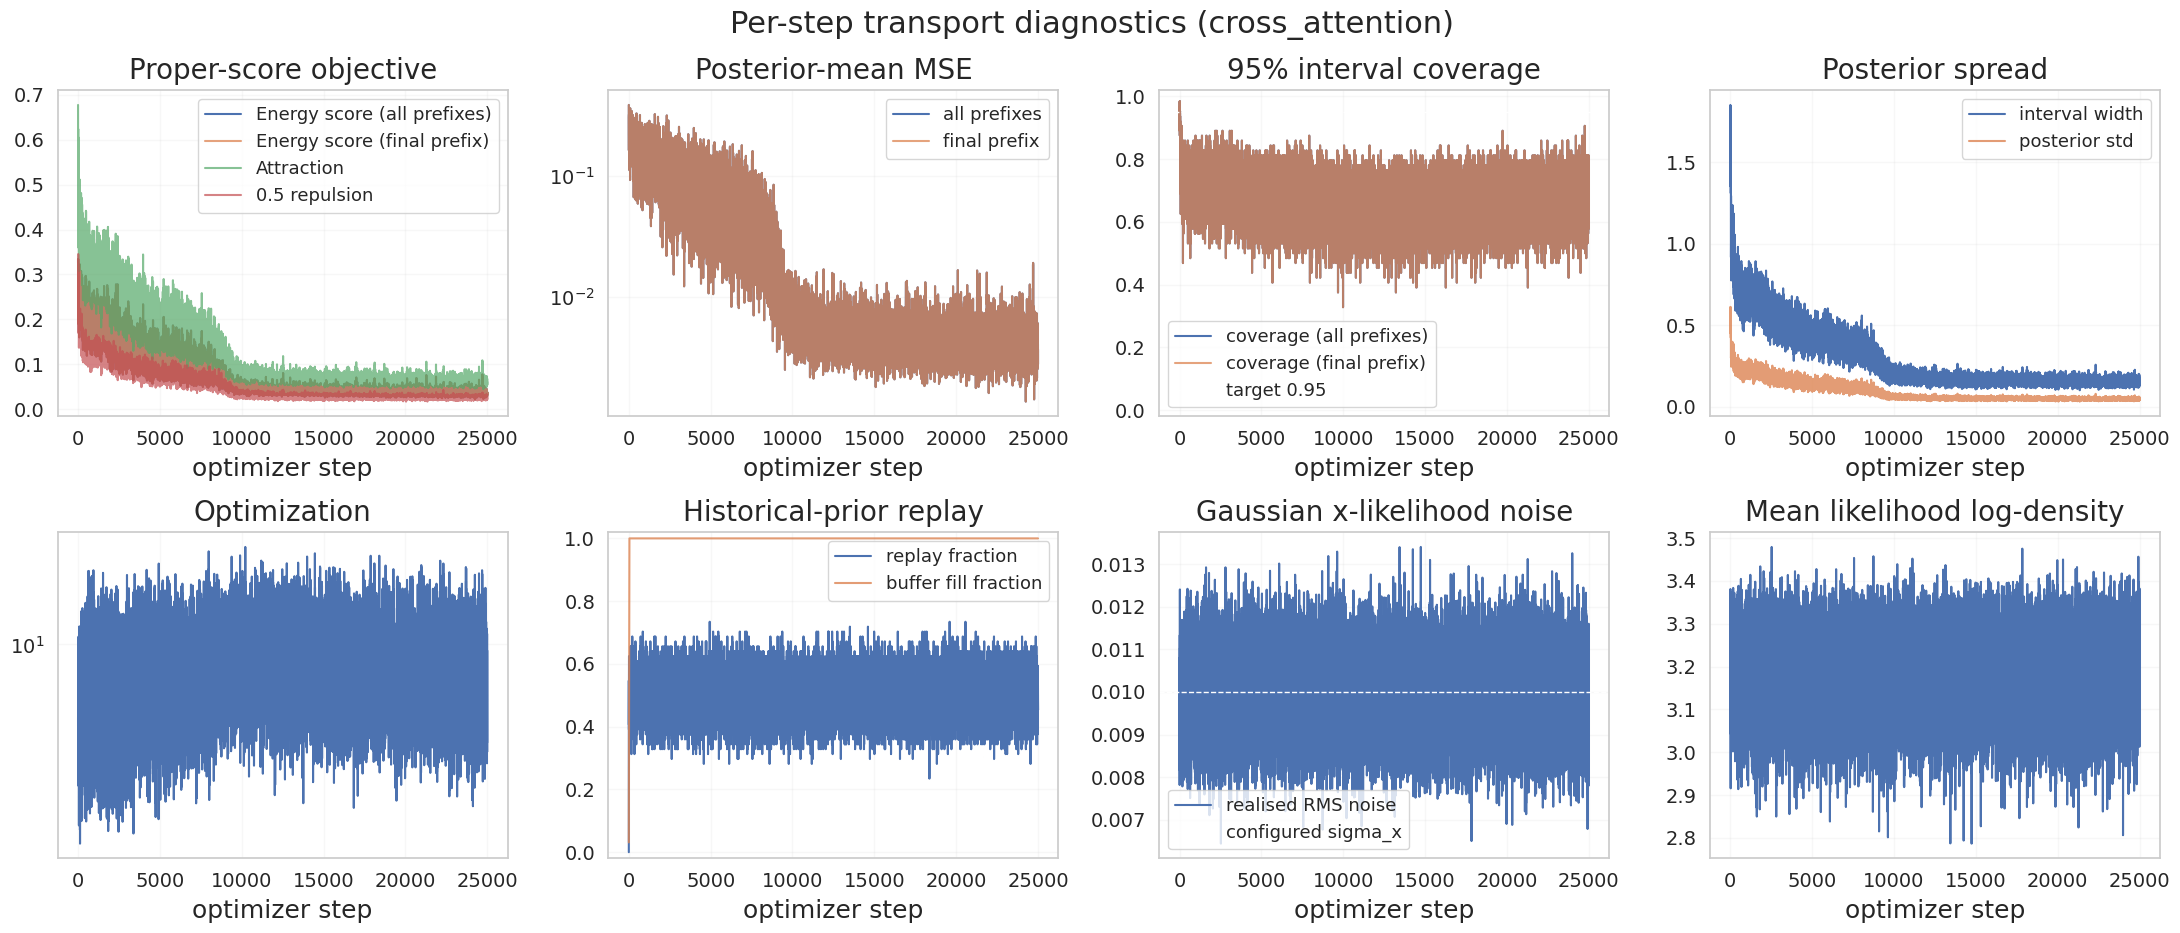


Training is complete. Training/evaluation prior families are independent: re-run the evaluation cells below to inspect GP-derived or preserved legacy prior modes without retraining.


In [ ]:
# Build EVERY model before training so sizes are known before the first optimization/fit call.
# If fitted GP hyperparameters are requested for transport priors, the SAME baseline GP is fitted
# exactly once here before transport training. Its learned kernel_ is then cloned into a fresh
# UNFITTED GP prior sampler. If initial hyperparameters are requested, the baseline GP remains
# unfitted until the historical late-baseline fit below.
transport_init = ConditionalParticleTransport(CFG, scaling, key=jax.random.key(CFG.seed))
nn_init = StandardMLP(CFG, key=jax.random.key(CFG.seed))
gp_init = make_gp(CFG)
print_model_parameter_counts(transport_init, nn_init, gp_init, len(X_train))

gp: GaussianProcessRegressor | None = None
gp_prior_sampler: GaussianProcessRegressor | None = None
gp_prior_bank: GPFunctionPriorBank | None = None
gp_covariance_prior: GPCovariancePriorCloud | None = None

# GP prior objects are deliberately built before transport optimisation ONLY when training uses them.
# With evaluation-only GP priors, transport training is completely independent of GP prior clouds.
if gp_priors_enabled_for_training(CFG):
    if CFG.gp_prior_hyperparameter_source == "fitted":
        print("\n--- fitting GP ONCE to obtain TRAINING-prior kernel hyperparameters ---")
        gp = fit_gp(gp_init, X_train, Y_train)
        print("The fitted GP will be reused later as the baseline; it will NOT be fitted again.")
    else:
        print("\n--- using configured INITIAL GP kernel hyperparameters for TRAINING priors ---")

    gp_prior_sampler = make_gp_prior_sampler(gp_init if gp is None else gp, CFG)
    if CFG.gp_prior_representation == "covariance_cloud":
        print(
            "--- building pointwise GP-kernel-weighted Gaussian TRAINING prior clouds "
            f"with {CFG.gp_prior_hyperparameter_source.upper()} hyperparameters ---"
        )
        gp_covariance_prior = build_gp_covariance_prior_cloud(
            gp_prior_sampler, X_train, Y_train, X_test, CFG
        )
        print(
            f"Train prior mean std={np.mean(gp_covariance_prior.train_std):.4f} | "
            f"test prior mean std={np.mean(gp_covariance_prior.test_std):.4f} | "
            f"train mean support={np.mean(gp_covariance_prior.train_support):.3f} | "
            f"test mean support={np.mean(gp_covariance_prior.test_support):.3f}"
        )
        print("Each x gets one sampled Gaussian prior cloud; no Cholesky factor or prior averaging is used.")
    else:
        print(
            "--- sampling coherent GP TRAINING prior functions from a fresh UNFITTED GP "
            f"with {CFG.gp_prior_hyperparameter_source.upper()} hyperparameters ---"
        )
        gp_prior_bank = sample_gp_function_prior_bank(gp_prior_sampler, X_train, X_test, CFG)
        print(
            f"Sampled {gp_prior_bank.num_functions} joint GP prior functions over "
            f"{len(X_train)} train + {len(X_test)} test x values."
        )
    print(f"Transport-prior kernel: {gp_prior_sampler.kernel}")
else:
    print("\n--- transport training uses NO GP-derived priors ---")

print("\n--- training particle transport ---")
transport, history, posterior_replay_buffer = train_transport(
    X_train, Y_train, scaling, CFG, model=transport_init,
    gp_prior_train_values=(None if gp_prior_bank is None else gp_prior_bank.train_values),
    gp_prior_train_cloud=(None if gp_covariance_prior is None else gp_covariance_prior.train_cloud),
)

print("\n--- training standard MLP ONCE ---")
nn_model = train_mlp(X_train, Y_train, CFG, model=nn_init)
nn_train = predict_mlp(nn_model, X_train)
nn_test = predict_mlp(nn_model, X_test)

if gp is None:
    print("\n--- Gaussian Process ONCE ---")
    gp = fit_gp(gp_init, X_train, Y_train)
else:
    print("\n--- Gaussian Process baseline: reusing the GP already fitted ONCE above ---")
gp_train, gp_train_std = gp.predict(X_train[:, None], return_std=True)
gp_test, gp_test_std = gp.predict(X_test[:, None], return_std=True)

# Baseline metrics are cached here and reused by every later transport-prior evaluation.
mse = lambda y, p: float(np.mean((y - p) ** 2))
baseline_metrics = {
    "mlp": {"train_mse": mse(Y_train, nn_train), "test_mse": mse(Y_test, nn_test)},
    "gp": {
        "train_mse": mse(Y_train, gp_train),
        "test_mse": mse(Y_test, gp_test),
        "train_coverage_95": float(np.mean(np.abs(Y_train - gp_train) <= 1.96 * gp_train_std)),
        "test_coverage_95": float(np.mean(np.abs(Y_test - gp_test) <= 1.96 * gp_test_std)),
    },
}

with (out / "training_history.json").open("w") as f:
    json.dump(history, f, indent=2)
eqx.tree_serialise_leaves(out / "particle_transport.eqx", transport)
plot_training(history, out / "transport_training_diagnostics.pdf", CFG)

print(
    "\nTraining is complete. Training/evaluation prior families are independent: re-run the "
    "evaluation cells below to inspect GP-derived or preserved legacy prior modes without retraining."
)

In [ ]:
# All settings below are EVALUATION-ONLY. They can be changed after the transport, NN, and GP
# have been trained. Nothing in this dataclass enters transport/NN/GP training.
@dataclass
class EvaluationPriorConfig:
    # GP-informed priors reuse the GP that was already fitted ONCE in cell 8.
    gp_interval_z: float = 1.96

    # Smooth kernel/locality calculations. This is NOT a learned hyperparameter.
    kernel_length_scale: float = 0.15
    kernel_eps: float = 1e-12

    # GP-like kernel-support prior: narrow/local near support, widest/global far from support.
    kernel_support_local_width_fraction: float = 0.50

    # Extremely simple nearest-output prior.
    nearest_fixed_width_fraction: float = 0.50

    # Local-variance / local-linear bounds.
    local_std_multiplier: float = 2.0
    local_linear_k: int = 64

    # Simple k-neighbour quantile/envelope rules.
    knn_quantile_low: float = 0.05
    knn_quantile_high: float = 0.95
    simple_margin: float = 0.25
    simple_min_width: float = 1.00

    # Distance-expanded kNN envelope: add this fraction of the widest prior for each
    # kernel-length-scale of distance from the nearest training x, capped at widest width.
    distance_envelope_growth: float = 0.50

    # Split-conformal-style calibration used only to choose a bound width. No model is trained.
    conformal_alpha: float = 0.05
    conformal_calibration_fraction: float = 0.20

    # Sequential nearest-posterior deployment. batch_size=1 is exact point-by-point propagation.
    # Larger values process equally "outward" groups together, then add the whole batch of newly
    # predicted posterior clouds to the working buffer before moving farther out of support.
    nearest_posterior_deployment_batch_size: int = 1

    # New evaluation modes may extend beyond the widest training support. Set True if you want
    # every new mode forcibly clipped back to [CFG.prior_min, CFG.prior_max]. Existing
    # nearest_training keeps using CFG.eval_local_prior_clip_to_global exactly as before.
    clip_new_modes_to_global: bool = False


EVAL_PRIOR_CFG = EvaluationPriorConfig()


AVAILABLE_EVAL_PRIOR_MODES = {
    # Existing modes.
    "cheating": "oracle label centre; diagnostic upper benchmark only",
    "widest": "the base-prior effective span (hard support for Uniform; +/-z sigma for Gaussian)",
    "nearest_training": "kNN min/max y envelope + fixed margin (existing method)",
    "nearest_posterior": "sequentially reuse the closest previously achieved posterior cloud",

    # GP-informed modes: reuse the already fitted GP; NEVER refit it here.
    "gp_variance_matched": "selected prior family with GP predictive mean and matched variance",
    "gp_95": "selected prior family using GP mean +/- configured z * GP predictive std span",

    # GP-like but no GP is used or fitted.
    "kernel_support": "kernel local centre; width and centre revert toward the global prior OOD",
    "nearest_distance": "nearest observed y centre; width grows smoothly with distance to support",
    "kernel_local_variance": "kernel local mean/std plus support-dependent OOD widening",
    "local_linear": "local weighted linear extrapolation plus residual/support-dependent width",
    "conformal_kernel": "split-conformal-style constant residual bound around a kernel centre",
    "kernel_conformal": "conformal in-domain width that widens toward the global prior OOD",

    # Very simple, deliberately non-GP ideas: just construct a plausible interval.
    "train_y_range": "same observed training-y min/max envelope everywhere, plus a margin",
    "nearest_y_fixed": "nearest training y as centre with one fixed width everywhere",
    "knn_quantile": "local kNN y quantiles + margin; robust to extreme neighbours",
    "knn_range_distance": "local kNN min/max envelope that widens with distance from support",
}


def print_evaluation_prior_catalog() -> None:
    print("\nAvailable post-training evaluation-prior modes:")
    for name, description in AVAILABLE_EVAL_PRIOR_MODES.items():
        print(f"  {name:22s} : {description}")


def _as_1d_float(x: np.ndarray) -> np.ndarray:
    return np.asarray(x, dtype=np.float64).reshape(-1)


def _global_prior_geometry(scaling: Scaling) -> tuple[float, float, float]:
    low = float(scaling.prior_low)
    high = float(scaling.prior_high)
    return 0.5 * (low + high), high - low, 0.5 * (high - low)


def _ensure_min_width(
    center: np.ndarray,
    half: np.ndarray | float,
    min_width: float,
) -> tuple[np.ndarray, np.ndarray]:
    center = _as_1d_float(center)
    half = np.broadcast_to(np.asarray(half, dtype=np.float64), center.shape).copy()
    half = np.maximum(half, 0.5 * float(min_width))
    return center - half, center + half


def _clip_bounds_to_global_if_requested(
    low: np.ndarray,
    high: np.ndarray,
    scaling: Scaling,
    *,
    clip: bool,
) -> tuple[np.ndarray, np.ndarray]:
    low = _as_1d_float(low)
    high = _as_1d_float(high)
    if not clip:
        return low, high
    width = high - low
    global_width = float(scaling.prior_high - scaling.prior_low)
    width = np.minimum(width, global_width)
    half = 0.5 * width
    center = 0.5 * (low + high)
    center = np.clip(
        center,
        float(scaling.prior_low) + half,
        float(scaling.prior_high) - half,
    )
    return center - half, center + half


def _nearest_indices_and_distances(
    x_query: np.ndarray,
    x_train: np.ndarray,
    k: int,
) -> tuple[np.ndarray, np.ndarray]:
    x_query = _as_1d_float(x_query)
    x_train = _as_1d_float(x_train)
    if len(x_train) == 0:
        raise ValueError("At least one training pair is required to construct this prior.")
    k = min(max(int(k), 1), len(x_train))
    distances = np.abs(x_query[:, None] - x_train[None, :])
    nearest = np.argpartition(distances, kth=k - 1, axis=1)[:, :k]
    nearest_distance = np.min(distances, axis=1)
    return nearest, nearest_distance


def _support_score_from_distance(distance: np.ndarray, length_scale: float) -> np.ndarray:
    """Simple support score in [0,1]: 1 near training x, ->0 away from support."""
    ell = max(float(length_scale), 1e-12)
    d = np.asarray(distance, dtype=np.float64)
    return np.exp(-0.5 * (d / ell) ** 2)


def _kernel_local_moments(
    x_query: np.ndarray,
    x_train: np.ndarray,
    y_train: np.ndarray,
    length_scale: float,
    eps: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Gaussian-kernel local mean/std plus absolute support score; no fitting/optimization."""
    xq = _as_1d_float(x_query)
    xt = _as_1d_float(x_train)
    yt = _as_1d_float(y_train)
    ell = max(float(length_scale), 1e-12)
    dist = np.abs(xq[:, None] - xt[None, :])
    w = np.exp(-0.5 * (dist / ell) ** 2)
    support = np.max(w, axis=1)
    wsum = np.sum(w, axis=1, keepdims=True)
    normalized = w / np.maximum(wsum, float(eps))
    mean = np.sum(normalized * yt[None, :], axis=1)
    var = np.sum(normalized * (yt[None, :] - mean[:, None]) ** 2, axis=1)

    # If every weight numerically vanishes, normalized weights carry no information.
    dead = (wsum[:, 0] <= float(eps))
    if np.any(dead):
        mean[dead] = float(np.mean(yt))
        var[dead] = float(np.var(yt))
        support[dead] = 0.0
    return mean, np.sqrt(np.maximum(var, 0.0)), support


def _local_linear_center_residual_std(
    x_query: np.ndarray,
    x_train: np.ndarray,
    y_train: np.ndarray,
    *,
    k: int,
    length_scale: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Tiny weighted local linear fits, solved independently per query; no learned model."""
    xq = _as_1d_float(x_query)
    xt = _as_1d_float(x_train)
    yt = _as_1d_float(y_train)
    nearest, nearest_distance = _nearest_indices_and_distances(xq, xt, k)
    ell = max(float(length_scale), 1e-12)
    centers = np.empty(len(xq), dtype=np.float64)
    residual_std = np.empty(len(xq), dtype=np.float64)

    for i, (x0, ids) in enumerate(zip(xq, nearest)):
        dx = xt[ids] - x0
        yy = yt[ids]
        w = np.exp(-0.5 * (dx / ell) ** 2)
        # Fit y = a + b (x-x0), so a is the prediction exactly at x0.
        A = np.column_stack([np.ones_like(dx), dx])
        sw = np.sqrt(np.maximum(w, 1e-12))
        coef, *_ = np.linalg.lstsq(A * sw[:, None], yy * sw, rcond=None)
        pred_local = A @ coef
        centers[i] = coef[0]
        residual_std[i] = np.sqrt(
            np.sum(w * (yy - pred_local) ** 2) / max(np.sum(w), 1e-12)
        )

    support = _support_score_from_distance(nearest_distance, ell)
    return centers, residual_std, support


def _split_conformal_kernel_components(
    x_query: np.ndarray,
    x_train: np.ndarray,
    y_train: np.ndarray,
    eval_cfg: EvaluationPriorConfig,
    *,
    seed: int,
) -> tuple[np.ndarray, float, np.ndarray]:
    """Simple deterministic split-conformal-style kernel bound; no fitted regressor.

    This is useful as an intuitive calibration rule. Its usual exchangeability coverage
    interpretation should NOT be assumed for genuinely out-of-support queries.
    """
    xt = _as_1d_float(x_train)
    yt = _as_1d_float(y_train)
    n = len(xt)
    if n < 5:
        raise ValueError("conformal_kernel requires at least five training observations.")
    frac = float(eval_cfg.conformal_calibration_fraction)
    if not 0.0 < frac < 1.0:
        raise ValueError("conformal_calibration_fraction must lie in (0,1).")
    alpha = float(eval_cfg.conformal_alpha)
    if not 0.0 < alpha < 1.0:
        raise ValueError("conformal_alpha must lie in (0,1).")

    rng = np.random.default_rng(seed)
    perm = rng.permutation(n)
    n_cal = min(max(int(round(frac * n)), 1), n - 2)
    cal_ids = perm[:n_cal]
    ref_ids = perm[n_cal:]

    cal_center, _, _ = _kernel_local_moments(
        xt[cal_ids], xt[ref_ids], yt[ref_ids],
        eval_cfg.kernel_length_scale, eval_cfg.kernel_eps,
    )
    residuals = np.abs(yt[cal_ids] - cal_center)
    # Finite-sample split-conformal quantile, using the conservative 'higher' order statistic.
    level = min(1.0, np.ceil((n_cal + 1) * (1.0 - alpha)) / n_cal)
    try:
        q = float(np.quantile(residuals, level, method="higher"))
    except TypeError:  # NumPy < 1.22 compatibility.
        q = float(np.quantile(residuals, level, interpolation="higher"))

    query_center, _, support = _kernel_local_moments(
        x_query, xt[ref_ids], yt[ref_ids],
        eval_cfg.kernel_length_scale, eval_cfg.kernel_eps,
    )
    return query_center, q, support


def evaluation_prior_bounds_np(
    x_query: np.ndarray,
    x_train: np.ndarray,
    y_train: np.ndarray,
    scaling: Scaling,
    cfg: Config,
    *,
    mode: str | None = None,
    y_query_oracle: np.ndarray | None = None,
    gp_model: GaussianProcessRegressor | None = None,
    eval_cfg: EvaluationPriorConfig = EVAL_PRIOR_CFG,
) -> tuple[np.ndarray, np.ndarray]:
    """Return one post-training evaluation y-prior interval per query x.

    No mode here retrains the transport, NN, or GP. ``cheating`` deliberately uses the true
    query label. GP modes reuse the already-fitted ``gp_model``. Every other mode is built
    directly from the closed training set with simple deterministic NumPy calculations.
    """
    mode = cfg.evaluation_prior_mode if mode is None else str(mode)
    if mode not in AVAILABLE_EVAL_PRIOR_MODES:
        raise ValueError(
            f"Unknown evaluation prior mode {mode!r}. Available: {sorted(AVAILABLE_EVAL_PRIOR_MODES)}"
        )
    if mode == "nearest_posterior":
        raise ValueError(
            "nearest_posterior is a dynamic empirical-cloud prior. Use the dedicated "
            "nearest-posterior preview/prediction helpers instead of interval construction."
        )

    xq = _as_1d_float(x_query)
    xt = _as_1d_float(x_train)
    yt = _as_1d_float(y_train)
    if len(xt) < 1:
        raise ValueError("At least one training pair is required for evaluation-prior construction.")

    global_center, global_width, global_half = _global_prior_geometry(scaling)
    min_width = float(eval_cfg.simple_min_width)

    # ---- Existing modes: preserved exactly. ----
    if mode == "cheating":
        if y_query_oracle is None:
            raise ValueError(
                "cheating evaluation prior requires y_query_oracle (the known evaluation labels)."
            )
        y_oracle = _as_1d_float(y_query_oracle)
        if len(y_oracle) != len(xq):
            raise ValueError("y_query_oracle must have the same length as x_query.")
        cheating_width = float(cfg.cheating_prior_width_fraction) * global_width
        half = 0.5 * cheating_width
        return (y_oracle - half).astype(np.float32), (y_oracle + half).astype(np.float32)

    if mode == "widest":
        low = np.full(len(xq), scaling.prior_low, dtype=np.float32)
        high = np.full(len(xq), scaling.prior_high, dtype=np.float32)
        return low, high

    if mode == "nearest_training":
        nearest, _ = _nearest_indices_and_distances(xq, xt, cfg.eval_local_prior_k)
        local_y = yt[nearest]
        raw_low = np.min(local_y, axis=1)
        raw_high = np.max(local_y, axis=1)
        center = 0.5 * (raw_low + raw_high)
        half = 0.5 * (raw_high - raw_low) + float(cfg.eval_local_prior_margin)
        half = np.maximum(half, 0.5 * float(cfg.eval_local_prior_min_width))
        low, high = center - half, center + half
        low, high = _clip_bounds_to_global_if_requested(
            low, high, scaling, clip=bool(cfg.eval_local_prior_clip_to_global)
        )
        return low.astype(np.float32), high.astype(np.float32)

    # ---- GP-informed priors: reuse the GP fitted once in cell 8. ----
    if mode in {"gp_variance_matched", "gp_95"}:
        if gp_model is None:
            raise ValueError(f"{mode} requires the already-fitted gp_model; it is not refit here.")
        gp_mean, gp_std = gp_model.predict(xq[:, None], return_std=True)
        if mode == "gp_variance_matched":
            if cfg.base_prior_distribution == "uniform":
                # Uniform(mu-h,mu+h) has variance h^2/3.
                half = np.sqrt(3.0) * gp_std
            else:
                # Gaussian evaluation bounds represent +/- gaussian_prior_visual_z sigma.
                half = float(cfg.gaussian_prior_visual_z) * gp_std
        else:
            half = float(eval_cfg.gp_interval_z) * gp_std
        low, high = _ensure_min_width(gp_mean, half, min_width)
        low, high = _clip_bounds_to_global_if_requested(
            low, high, scaling, clip=eval_cfg.clip_new_modes_to_global
        )
        return low.astype(np.float32), high.astype(np.float32)

    # Shared locality ingredients for several no-fit modes.
    kernel_mean, kernel_std, support = _kernel_local_moments(
        xq, xt, yt, eval_cfg.kernel_length_scale, eval_cfg.kernel_eps
    )
    _, nearest_distance = _nearest_indices_and_distances(xq, xt, 1)

    if mode == "kernel_support":
        # GP-like qualitative behavior without a GP: locally informed near support, then both
        # centre and width continuously revert to the configured global prior as support vanishes.
        local_width = max(
            float(eval_cfg.kernel_support_local_width_fraction) * global_width,
            min_width,
        )
        center = support * kernel_mean + (1.0 - support) * global_center
        width = support * local_width + (1.0 - support) * global_width
        low, high = center - 0.5 * width, center + 0.5 * width

    elif mode == "nearest_distance":
        # Extremely simple: nearest y gives the centre; only nearest-x distance controls width.
        nearest, nearest_distance = _nearest_indices_and_distances(xq, xt, 1)
        center = yt[nearest[:, 0]]
        s = _support_score_from_distance(nearest_distance, eval_cfg.kernel_length_scale)
        local_width = max(float(eval_cfg.nearest_fixed_width_fraction) * global_width, min_width)
        width = s * local_width + (1.0 - s) * global_width
        low, high = center - 0.5 * width, center + 0.5 * width

    elif mode == "kernel_local_variance":
        # Local disagreement sets the ID width; lack of support smoothly restores global width.
        local_half = np.maximum(
            float(eval_cfg.local_std_multiplier) * kernel_std,
            0.5 * min_width,
        )
        half = support * local_half + (1.0 - support) * global_half
        center = support * kernel_mean + (1.0 - support) * global_center
        low, high = center - half, center + half

    elif mode == "local_linear":
        center_local, residual_std, s = _local_linear_center_residual_std(
            xq, xt, yt,
            k=eval_cfg.local_linear_k,
            length_scale=eval_cfg.kernel_length_scale,
        )
        local_half = np.maximum(
            float(eval_cfg.local_std_multiplier) * residual_std + float(eval_cfg.simple_margin),
            0.5 * min_width,
        )
        # Retain extrapolative center while supported; revert toward global center far OOD.
        center = s * center_local + (1.0 - s) * global_center
        half = s * local_half + (1.0 - s) * global_half
        low, high = center - half, center + half

    elif mode in {"conformal_kernel", "kernel_conformal"}:
        center, conformal_half, s = _split_conformal_kernel_components(
            xq, xt, yt, eval_cfg, seed=cfg.seed + 71_001
        )
        conformal_half = max(float(conformal_half), 0.5 * min_width)
        if mode == "conformal_kernel":
            half = np.full(len(xq), conformal_half, dtype=np.float64)
        else:
            # Same conformal-calibrated ID width, but admit ignorance OOD by widening globally.
            half = s * conformal_half + (1.0 - s) * global_half
            center = s * center + (1.0 - s) * global_center
        low, high = center - half, center + half

    # ---- Deliberately simple non-GP bounds. ----
    elif mode == "train_y_range":
        low0 = float(np.min(yt)) - float(eval_cfg.simple_margin)
        high0 = float(np.max(yt)) + float(eval_cfg.simple_margin)
        center0 = 0.5 * (low0 + high0)
        half0 = max(0.5 * (high0 - low0), 0.5 * min_width)
        low = np.full(len(xq), center0 - half0)
        high = np.full(len(xq), center0 + half0)

    elif mode == "nearest_y_fixed":
        nearest, _ = _nearest_indices_and_distances(xq, xt, 1)
        center = yt[nearest[:, 0]]
        width = max(float(eval_cfg.nearest_fixed_width_fraction) * global_width, min_width)
        low, high = center - 0.5 * width, center + 0.5 * width

    elif mode == "knn_quantile":
        nearest, _ = _nearest_indices_and_distances(xq, xt, cfg.eval_local_prior_k)
        local_y = yt[nearest]
        qlo = float(eval_cfg.knn_quantile_low)
        qhi = float(eval_cfg.knn_quantile_high)
        if not 0.0 <= qlo < qhi <= 1.0:
            raise ValueError("knn quantiles must satisfy 0 <= low < high <= 1.")
        raw_low = np.quantile(local_y, qlo, axis=1) - float(eval_cfg.simple_margin)
        raw_high = np.quantile(local_y, qhi, axis=1) + float(eval_cfg.simple_margin)
        center = 0.5 * (raw_low + raw_high)
        half = np.maximum(0.5 * (raw_high - raw_low), 0.5 * min_width)
        low, high = center - half, center + half

    elif mode == "knn_range_distance":
        nearest, nearest_distance = _nearest_indices_and_distances(xq, xt, cfg.eval_local_prior_k)
        local_y = yt[nearest]
        raw_low = np.min(local_y, axis=1) - float(eval_cfg.simple_margin)
        raw_high = np.max(local_y, axis=1) + float(eval_cfg.simple_margin)
        center = 0.5 * (raw_low + raw_high)
        base_width = np.maximum(raw_high - raw_low, min_width)
        ell = max(float(eval_cfg.kernel_length_scale), 1e-12)
        extra = (
            float(eval_cfg.distance_envelope_growth)
            * global_width
            * (nearest_distance / ell)
        )
        width = np.minimum(base_width + extra, global_width)
        low, high = center - 0.5 * width, center + 0.5 * width

    else:  # Defensive; AVAILABLE_EVAL_PRIOR_MODES already checked above.
        raise RuntimeError(f"Unhandled evaluation prior mode: {mode}")

    low, high = _clip_bounds_to_global_if_requested(
        low, high, scaling, clip=eval_cfg.clip_new_modes_to_global
    )
    return np.asarray(low, dtype=np.float32), np.asarray(high, dtype=np.float32)


def _prior_bounds_summary(low: np.ndarray, high: np.ndarray) -> str:
    width = np.asarray(high) - np.asarray(low)
    center = 0.5 * (np.asarray(low) + np.asarray(high))
    return (
        f"width min/median/max={width.min():.3f}/{np.median(width):.3f}/{width.max():.3f} | "
        f"center min/median/max={center.min():.3f}/{np.median(center):.3f}/{center.max():.3f}"
    )


def sample_evaluation_prior_from_bounds_np(
    rng: np.random.Generator,
    prior_low: np.ndarray,
    prior_high: np.ndarray,
    n_particles: int,
    cfg: Config = CFG,
) -> np.ndarray:
    """Sample the selected prior family from per-query effective interval geometry.

    Uniform mode treats low/high as literal hard bounds. Gaussian mode interprets their midpoint
    as mu and their half-width as gaussian_prior_visual_z*sigma. This lets every existing
    post-training prior-selection rule work without a second Gaussian-specific catalog.
    """
    low = np.asarray(prior_low, dtype=np.float32).reshape(-1)
    high = np.asarray(prior_high, dtype=np.float32).reshape(-1)
    if np.any(high <= low):
        raise ValueError("Every evaluation prior interval must have positive effective width.")
    center = 0.5 * (low + high)
    half = 0.5 * (high - low)
    if cfg.base_prior_distribution == "uniform":
        u = rng.uniform(0.0, 1.0, (len(low), int(n_particles))).astype(np.float32)
        return (low[:, None] + (high - low)[:, None] * u).astype(np.float32)
    sigma = half / float(cfg.gaussian_prior_visual_z)
    return rng.normal(
        loc=center[:, None],
        scale=sigma[:, None],
        size=(len(low), int(n_particles)),
    ).astype(np.float32)


def make_deployment_observation_block_np(
    x: np.ndarray,
    cfg: Config,
    *,
    num_observations: int | None = None,
) -> np.ndarray:
    """Build clean deployment likelihood observations; NO Gaussian noise is added here.

    DIRECT mode always returns exactly one clean observed x per query, matching the attached
    historical cosine implementation. TRANSFORMER mode may repeat the clean observed query x
    to the requested trained prefix length, preserving the previous deployment convention.
    """
    if cfg.likelihood_conditioning_mode == "direct":
        n_obs = 1 if num_observations is None else int(num_observations)
        if n_obs != 1:
            raise ValueError(
                "Direct likelihood mode uses exactly ONE deployment observation. "
                "Set num_observations=1 (or leave it unset)."
            )
    else:
        n_obs = cfg.test_observations_per_step if num_observations is None else int(num_observations)
        if not (cfg.min_observations_per_step <= n_obs <= cfg.max_observations_per_step):
            raise ValueError(
                "Transformer deployment num_observations must lie in the trained prefix range "
                f"[{cfg.min_observations_per_step}, {cfg.max_observations_per_step}]."
            )
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if cfg.likelihood_conditioning_mode == "direct":
        return x  # [B]: one clean scalar x per query, exactly the historical direct interface.
    return np.repeat(x[:, None], n_obs, axis=1).astype(np.float32)


@eqx.filter_jit
def _predict_batch(
    model: ConditionalParticleTransport,
    prior: Array,
    x_observations: Array,
    observation_count: Array,
) -> Array:
    if model.likelihood_conditioning_mode == "direct":
        return jax.vmap(model.direct_transport)(prior, x_observations)
    return jax.vmap(lambda p, obs: model(p, obs, observation_count))(prior, x_observations)


def predict_transport_from_bounds(
    model: ConditionalParticleTransport,
    x: np.ndarray,
    prior_low: np.ndarray,
    prior_high: np.ndarray,
    cfg: Config,
    *,
    seed: int,
    prior_mode: str,
    num_observations: int | None = None,
) -> dict[str, np.ndarray]:
    """Predict from already-built prior bounds with clean deployment x observations.

    Prior construction is intentionally separated from transport evaluation so the entire prior
    range can be inspected BEFORE the model sees the test set. Deployment x is NOT noisified.
    In direct mode exactly ONE clean x is supplied. In Transformer mode `num_observations`
    selects the clean evidence-prefix length.
    """
    x = np.asarray(x).reshape(-1)
    prior_low = np.asarray(prior_low, dtype=np.float32).reshape(-1)
    prior_high = np.asarray(prior_high, dtype=np.float32).reshape(-1)
    if len(prior_low) != len(x) or len(prior_high) != len(x):
        raise ValueError("prior_low/prior_high must have one bound per query x.")
    if np.any(prior_high <= prior_low):
        raise ValueError("Every evaluation prior interval must have positive width.")

    if cfg.likelihood_conditioning_mode == "direct":
        n_obs = 1 if num_observations is None else int(num_observations)
    else:
        n_obs = cfg.test_observations_per_step if num_observations is None else int(num_observations)
    x_observations = make_deployment_observation_block_np(
        x, cfg, num_observations=n_obs
    )

    rng = np.random.default_rng(seed)
    clouds: list[np.ndarray] = []
    for start in range(0, len(x), cfg.eval_batch_size):
        xb_obs = x_observations[start:start + cfg.eval_batch_size]
        lo = prior_low[start:start + cfg.eval_batch_size]
        hi = prior_high[start:start + cfg.eval_batch_size]
        prior = sample_evaluation_prior_from_bounds_np(
            rng, lo, hi, cfg.eval_particles, cfg
        )
        cloud = _predict_batch(
            model,
            jnp.asarray(prior),
            jnp.asarray(xb_obs),
            jnp.asarray(n_obs, dtype=jnp.int32),
        )
        clouds.append(np.asarray(jax.device_get(cloud)))
    cloud = np.concatenate(clouds, axis=0)
    return {
        "cloud": cloud,
        "mean": cloud.mean(axis=1),
        "std": cloud.std(axis=1),
        "low": np.quantile(cloud, cfg.interval_low_q, axis=1),
        "high": np.quantile(cloud, cfg.interval_high_q, axis=1),
        "prior_low": prior_low,
        "prior_high": prior_high,
        "prior_width": prior_high - prior_low,
        "prior_mode": str(prior_mode),
        "prior_distribution": cfg.base_prior_distribution,
        "num_observations": int(n_obs),
    }



def predict_transport_gp_covariance_cloud(
    model: ConditionalParticleTransport,
    x: np.ndarray,
    prior_cloud: np.ndarray,
    cfg: Config,
    *,
    num_observations: int | None = None,
) -> dict[str, np.ndarray]:
    """Transport one pre-sampled kernel-weighted Gaussian prior cloud; no model averaging."""
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    prior = np.asarray(prior_cloud, dtype=np.float32)
    if prior.shape != (len(x), cfg.eval_particles):
        raise ValueError("prior_cloud must have shape [len(x), cfg.eval_particles].")
    if cfg.likelihood_conditioning_mode == "direct":
        n_obs = 1 if num_observations is None else int(num_observations)
    else:
        n_obs = cfg.test_observations_per_step if num_observations is None else int(num_observations)
    x_observations = make_deployment_observation_block_np(x, cfg, num_observations=n_obs)

    clouds: list[np.ndarray] = []
    for start in range(0, len(x), cfg.eval_batch_size):
        stop = start + cfg.eval_batch_size
        cloud = _predict_batch(
            model, jnp.asarray(prior[start:stop]), jnp.asarray(x_observations[start:stop]),
            jnp.asarray(n_obs, dtype=jnp.int32),
        )
        clouds.append(np.asarray(jax.device_get(cloud), dtype=np.float32))
    posterior = np.concatenate(clouds, axis=0)
    prior_low = np.quantile(prior, cfg.interval_low_q, axis=1)
    prior_high = np.quantile(prior, cfg.interval_high_q, axis=1)
    return {
        "cloud": posterior,
        "mean": posterior.mean(axis=1),
        "std": posterior.std(axis=1),
        "low": np.quantile(posterior, cfg.interval_low_q, axis=1),
        "high": np.quantile(posterior, cfg.interval_high_q, axis=1),
        "prior_low": prior_low,
        "prior_high": prior_high,
        "prior_width": prior_high - prior_low,
        "prior_mode": "gp_covariance_cloud",
        "prior_distribution": "kernel_weighted_pointwise_gaussian",
        "num_observations": int(n_obs),
        "num_prior_samples": 1,
        "prior_cloud": prior,
    }


def predict_transport_gp_function_priors(
    model: ConditionalParticleTransport,
    x: np.ndarray,
    gp_function_values: np.ndarray,
    cfg: Config,
    *,
    seed: int,
    num_prior_samples: int | None = None,
    num_observations: int | None = None,
) -> dict[str, np.ndarray]:
    """Evaluate many coherent GP-function priors in parallel and return their equal-weight mixture.

    ``gp_function_values`` has shape [K,Q], with one row per sampled function and one column per
    query x. Each row produces one complete posterior cloud over all Q query points. We flatten the
    [prior-sample, query] axes only for batched transport execution, then restore them afterwards.

    The reported aggregate ``cloud`` concatenates particles from all prior-specific posterior
    clouds. Its mean is therefore exactly the average posterior mean across GP prior functions,
    while its quantiles retain both within-cloud uncertainty and variation between prior functions.
    """
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    values = np.asarray(gp_function_values, dtype=np.float32)
    if values.ndim != 2 or values.shape[1] != len(x):
        raise ValueError("gp_function_values must have shape [num_functions, len(x)].")
    k = cfg.gp_prior_eval_samples if num_prior_samples is None else int(num_prior_samples)
    if not (1 <= k <= values.shape[0]):
        raise ValueError("num_prior_samples must lie in [1, gp_function_values.shape[0]].")
    values = values[:k]

    if cfg.likelihood_conditioning_mode == "direct":
        n_obs = 1 if num_observations is None else int(num_observations)
    else:
        n_obs = cfg.test_observations_per_step if num_observations is None else int(num_observations)
    x_observations = make_deployment_observation_block_np(x, cfg, num_observations=n_obs)

    rng = np.random.default_rng(seed)
    prior_by_function = np.empty((k, len(x), cfg.eval_particles), dtype=np.float32)
    for function_id in range(k):
        prior_by_function[function_id] = sample_gp_function_particle_prior_np(
            rng, values[function_id], cfg.eval_particles, cfg
        )

    flat_prior = prior_by_function.reshape(k * len(x), cfg.eval_particles)
    if cfg.likelihood_conditioning_mode == "direct":
        flat_observations = np.tile(x_observations, k)
    else:
        flat_observations = np.tile(x_observations, (k, 1))

    flat_clouds: list[np.ndarray] = []
    for start in range(0, len(flat_prior), cfg.eval_batch_size):
        stop = start + cfg.eval_batch_size
        cloud = _predict_batch(
            model,
            jnp.asarray(flat_prior[start:stop]),
            jnp.asarray(flat_observations[start:stop]),
            jnp.asarray(n_obs, dtype=jnp.int32),
        )
        flat_clouds.append(np.asarray(jax.device_get(cloud), dtype=np.float32))

    posterior_by_function = np.concatenate(flat_clouds, axis=0).reshape(
        k, len(x), cfg.eval_particles
    )
    # Equal-weight Bayesian-style model average over sampled prior functions. Concatenating equal
    # particle counts is equivalent to an equally weighted empirical mixture of posterior clouds.
    mixture_cloud = posterior_by_function.transpose(1, 0, 2).reshape(len(x), k * cfg.eval_particles)
    mixture_prior = prior_by_function.transpose(1, 0, 2).reshape(len(x), k * cfg.eval_particles)

    return {
        "cloud": mixture_cloud,
        "mean": mixture_cloud.mean(axis=1),
        "std": mixture_cloud.std(axis=1),
        "low": np.quantile(mixture_cloud, cfg.interval_low_q, axis=1),
        "high": np.quantile(mixture_cloud, cfg.interval_high_q, axis=1),
        "prior_low": np.quantile(mixture_prior, cfg.interval_low_q, axis=1),
        "prior_high": np.quantile(mixture_prior, cfg.interval_high_q, axis=1),
        "prior_width": (
            np.quantile(mixture_prior, cfg.interval_high_q, axis=1)
            - np.quantile(mixture_prior, cfg.interval_low_q, axis=1)
        ),
        "prior_mode": "gp_function_samples_average",
        "prior_distribution": "sampled_gp_function_plus_gaussian_particle_noise",
        "num_observations": int(n_obs),
        "num_prior_samples": int(k),
        "gp_function_mean_by_prior": values,
        "prior_cloud_by_prior": prior_by_function,
        "posterior_cloud_by_prior": posterior_by_function,
    }


def select_gp_function_prior_prediction(
    averaged_prediction: dict[str, np.ndarray],
    prior_index: int,
    cfg: Config = CFG,
) -> dict[str, np.ndarray]:
    """Extract the one-prior -> one-posterior-cloud view used by the individual plots."""
    posterior = np.asarray(averaged_prediction["posterior_cloud_by_prior"])[prior_index]
    prior = np.asarray(averaged_prediction["prior_cloud_by_prior"])[prior_index]
    function_mean = np.asarray(averaged_prediction["gp_function_mean_by_prior"])[prior_index]
    prior_low = np.quantile(prior, cfg.interval_low_q, axis=1)
    prior_high = np.quantile(prior, cfg.interval_high_q, axis=1)
    return {
        "cloud": posterior,
        "mean": posterior.mean(axis=1),
        "std": posterior.std(axis=1),
        "low": np.quantile(posterior, cfg.interval_low_q, axis=1),
        "high": np.quantile(posterior, cfg.interval_high_q, axis=1),
        "prior_low": prior_low,
        "prior_high": prior_high,
        "prior_width": prior_high - prior_low,
        "prior_mode": f"gp_function_sample_{int(prior_index):02d}",
        "prior_distribution": "sampled_gp_function_plus_gaussian_particle_noise",
        "num_observations": int(averaged_prediction["num_observations"]),
        "num_prior_samples": 1,
        "gp_function_mean": function_mean,
    }


def _nearest_distance_to_reference_1d(
    x_query: np.ndarray,
    x_reference: np.ndarray,
) -> np.ndarray:
    """Memory-efficient nearest distance on a 1-D reference set."""
    xq = np.asarray(x_query, dtype=np.float64).reshape(-1)
    xr = np.sort(np.asarray(x_reference, dtype=np.float64).reshape(-1))
    if len(xr) == 0:
        raise ValueError("x_reference must contain at least one point.")
    pos = np.searchsorted(xr, xq)
    left = np.clip(pos - 1, 0, len(xr) - 1)
    right = np.clip(pos, 0, len(xr) - 1)
    return np.minimum(np.abs(xq - xr[left]), np.abs(xq - xr[right]))


def nearest_posterior_prior_preview_np(
    x_query: np.ndarray,
    replay_buffer: HistoricalOutputPriorBuffer,
    cfg: Config,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Pre-inference preview using ONLY the nearest stored training-time posterior clouds.

    Later sequential deployment priors can differ because newly predicted OOD clouds are inserted
    after every propagation batch. This preview is therefore intentionally the t=0 buffer view.
    """
    clouds, source_x, _ = replay_buffer.nearest_clouds(x_query)
    low = np.quantile(clouds, cfg.interval_low_q, axis=1)
    high = np.quantile(clouds, cfg.interval_high_q, axis=1)
    mean = np.mean(clouds, axis=1)
    return low.astype(np.float32), high.astype(np.float32), mean.astype(np.float32), source_x


def predict_transport_nearest_posterior(
    model: ConditionalParticleTransport,
    x: np.ndarray,
    x_train_reference: np.ndarray,
    replay_buffer: HistoricalOutputPriorBuffer,
    cfg: Config,
    *,
    seed: int,
    propagation_batch_size: int,
    num_observations: int | None = None,
) -> dict[str, np.ndarray]:
    """Sequential OOD prediction using the closest previously achieved posterior as the next prior.

    Ordering is by distance from the ORIGINAL training support. The working replay buffer starts
    from the fixed training-time (x, posterior-cloud) memory. For each outward propagation batch:

      1. choose the nearest cloud currently in the working buffer for every query in that batch;
      2. use those empirical clouds directly as priors;
      3. predict the batch;
      4. insert the newly achieved (x, posterior-cloud) pairs into the working buffer.

    With propagation_batch_size=1 this is exact point-by-point continuation. Larger batches are
    faster: every point in a batch sees the buffer state that existed before that batch.
    """
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) == 0:
        raise ValueError("nearest_posterior evaluation requires at least one query point.")
    propagation_batch_size = int(propagation_batch_size)
    if propagation_batch_size < 1:
        raise ValueError("nearest_posterior_deployment_batch_size must be >= 1.")
    if len(replay_buffer) == 0:
        raise ValueError("nearest_posterior evaluation requires a non-empty training replay buffer.")

    if cfg.likelihood_conditioning_mode == "direct":
        n_obs = 1 if num_observations is None else int(num_observations)
    else:
        n_obs = cfg.test_observations_per_step if num_observations is None else int(num_observations)

    # Training clouds contain cfg.num_particles whereas evaluation may request cfg.eval_particles.
    # Bootstrap resampling changes only the empirical particle count, not the stored distribution.
    rng = np.random.default_rng(seed)
    working = replay_buffer.resampled_copy(cfg.eval_particles, rng)

    support_distance = _nearest_distance_to_reference_1d(x, x_train_reference)
    order = np.argsort(support_distance, kind="stable")

    cloud_out = np.empty((len(x), cfg.eval_particles), dtype=np.float32)
    prior_low = np.empty(len(x), dtype=np.float32)
    prior_high = np.empty(len(x), dtype=np.float32)
    prior_source_x = np.empty(len(x), dtype=np.float32)
    prior_source_distance = np.empty(len(x), dtype=np.float32)
    propagation_rank = np.empty(len(x), dtype=np.int32)

    for start in range(0, len(x), propagation_batch_size):
        ids = order[start:start + propagation_batch_size]

        prior_cloud, source_x, source_distance = working.nearest_clouds(x[ids])
        xb_obs = make_deployment_observation_block_np(
            x[ids], cfg, num_observations=n_obs
        )
        predicted = _predict_batch(
            model,
            jnp.asarray(prior_cloud),
            jnp.asarray(xb_obs),
            jnp.asarray(n_obs, dtype=jnp.int32),
        )
        predicted = np.asarray(jax.device_get(predicted), dtype=np.float32)

        cloud_out[ids] = predicted
        prior_low[ids] = np.quantile(prior_cloud, cfg.interval_low_q, axis=1)
        prior_high[ids] = np.quantile(prior_cloud, cfg.interval_high_q, axis=1)
        prior_source_x[ids] = source_x
        prior_source_distance[ids] = source_distance
        propagation_rank[ids] = np.arange(start, start + len(ids), dtype=np.int32)

        # Newly achieved OOD posterior clouds become eligible priors only for FOLLOWING batches.
        working.add_batch(predicted, x[ids])

    return {
        "cloud": cloud_out,
        "mean": cloud_out.mean(axis=1),
        "std": cloud_out.std(axis=1),
        "low": np.quantile(cloud_out, cfg.interval_low_q, axis=1),
        "high": np.quantile(cloud_out, cfg.interval_high_q, axis=1),
        "prior_low": prior_low,
        "prior_high": prior_high,
        "prior_width": prior_high - prior_low,
        "prior_mode": "nearest_posterior",
        "prior_distribution": "empirical_posterior_cloud",
        "num_observations": int(n_obs),
        "prior_source_x": prior_source_x,
        "prior_source_distance": prior_source_distance,
        "support_distance": support_distance.astype(np.float32),
        "propagation_rank": propagation_rank,
        "propagation_batch_size": int(propagation_batch_size),
    }

def _energy_score_np_1d(cloud: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Exact 1-D empirical ES without materialising an [B,N,N] array."""
    attraction = np.mean(np.abs(cloud - y[:, None]), axis=1)
    z = np.sort(cloud, axis=1)
    n = z.shape[1]
    coeff = (2.0 * np.arange(n) - n + 1.0)[None, :]
    pairwise_mean = (2.0 / (n * n)) * np.sum(coeff * z, axis=1)
    return attraction - 0.5 * pairwise_mean


def evaluate_transport(pred: dict[str, np.ndarray], y: np.ndarray) -> dict[str, float]:
    return {
        "mse": float(np.mean((pred["mean"] - y) ** 2)),
        "mae": float(np.mean(np.abs(pred["mean"] - y))),
        "energy_score": float(np.mean(_energy_score_np_1d(pred["cloud"], y))),
        "coverage_95": float(np.mean((y >= pred["low"]) & (y <= pred["high"]))),
        "mean_interval_width": float(np.mean(pred["high"] - pred["low"])),
        "mean_posterior_std": float(np.mean(pred["std"])),
        "mean_prior_width": float(np.mean(pred["prior_width"])),
        "min_prior_width": float(np.min(pred["prior_width"])),
        "max_prior_width": float(np.max(pred["prior_width"])),
    }


def _true_line(ax, x_train, y_train, x_test, y_test):
    x = np.concatenate([x_train, x_test])
    y = np.concatenate([y_train, y_test])
    ix = np.argsort(x)
    ax.plot(x[ix], y[ix], c="black", linewidth=3, label="True Func.")
    ax.set_ylim(-2.5, 2.5)
    ax.grid(alpha=0.1)
    ax.set_xlabel("x")
    ax.tick_params(axis="both", labelsize=15)


def _sorted_contiguous_groups(x: np.ndarray) -> list[np.ndarray]:
    """Split sorted x values across large support gaps so shaded bands do not bridge them."""
    x = np.asarray(x).reshape(-1)
    order = np.argsort(x)
    if len(order) <= 1:
        return [order]
    xs = x[order]
    dx = np.diff(xs)
    positive = dx[dx > 0]
    if len(positive) == 0:
        return [order]
    threshold = max(8.0 * float(np.median(positive)), 0.04 * float(xs.max() - xs.min()))
    split_at = np.flatnonzero(dx > threshold) + 1
    return [g for g in np.split(order, split_at) if len(g)]


def _plot_shaded_interval(
    ax,
    x: np.ndarray,
    low: np.ndarray,
    high: np.ndarray,
    *,
    label: str,
    color: str,
    alpha: float = 0.28,
) -> None:
    """Draw non-overlapping uncertainty regions instead of dense vertical error bars."""
    first = True
    for group in _sorted_contiguous_groups(x):
        order = group[np.argsort(np.asarray(x)[group])]
        ax.fill_between(
            np.asarray(x)[order], np.asarray(low)[order], np.asarray(high)[order],
            color=color, alpha=alpha, linewidth=0,
            label=label if first else None,
        )
        first = False


def _plot_mean(
    ax,
    x: np.ndarray,
    mean: np.ndarray,
    *,
    label: str,
    color: str,
    lw: float = 2.2,
) -> None:
    """Plot predictive means, split across large x gaps so OOD regions are never bridged."""
    first = True
    for group in _sorted_contiguous_groups(x):
        order = group[np.argsort(np.asarray(x)[group])]
        ax.plot(
            np.asarray(x)[order], np.asarray(mean)[order],
            color=color, linewidth=lw,
            label=label if first else None,
        )
        first = False


def plot_gp_function_prior_bank(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_test: np.ndarray,
    prior_bank: GPFunctionPriorBank,
    path: Path,
    cfg: Config = CFG,
) -> None:
    """Inspect several coherent GP prior-function draws before transport test inference."""
    k = min(int(cfg.gp_prior_eval_samples), prior_bank.num_functions)
    x_all = np.concatenate([x_train, x_test])
    order = np.argsort(x_all)
    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.scatter(
        x_train, y_train, s=22, color="darkgreen", alpha=.40,
        label="known in-domain training pairs", zorder=4,
    )
    for function_id in range(k):
        f_all = np.concatenate([
            prior_bank.train_values[function_id],
            prior_bank.test_values[function_id],
        ])
        ax.plot(
            x_all[order], f_all[order], linewidth=1.15, alpha=.28,
            label="sampled unfitted-GP prior functions" if function_id == 0 else None,
        )
    # Make the configured particle width explicit around the first sampled function.
    first = np.concatenate([prior_bank.train_values[0], prior_bank.test_values[0]])
    noise_half = 1.96 * float(cfg.gp_prior_particle_noise_std)
    ax.fill_between(
        x_all[order], first[order] - noise_half, first[order] + noise_half,
        alpha=.12, linewidth=0, label="first f(x) +/- 1.96 particle-noise std",
    )
    ax.set_xlabel("x")
    ax.set_ylabel("GP prior function value")
    ax.set_title(
        f"PRIOR INSPECTION BEFORE TEST INFERENCE: {k} coherent samples from the UNFITTED GP\n"
        f"Transport particles are N(f(x), {cfg.gp_prior_particle_noise_std:.4f}^2)"
    )
    ax.grid(alpha=.15)
    ax.legend(loc="best")
    fig.tight_layout()
    _save_and_show(fig, path, cfg)


def plot_gp_covariance_prior_cloud(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_test: np.ndarray,
    prior_cloud: GPCovariancePriorCloud,
    path: Path,
    cfg: Config = CFG,
) -> None:
    """Inspect the kernel-weighted Gaussian prior clouds before transport inference."""
    x_all = np.concatenate([x_train, x_test])
    cloud_all = np.concatenate([prior_cloud.train_eval_cloud, prior_cloud.test_eval_cloud], axis=0)
    mean_all = np.concatenate([prior_cloud.train_mean, prior_cloud.test_mean])
    support_all = np.concatenate([prior_cloud.train_support, prior_cloud.test_support])
    order = np.argsort(x_all)
    low = np.quantile(cloud_all, cfg.interval_low_q, axis=1)
    high = np.quantile(cloud_all, cfg.interval_high_q, axis=1)

    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.scatter(
        x_train, y_train, s=22, color="darkgreen", alpha=.40,
        label="known in-domain training pairs", zorder=4,
    )
    ax.fill_between(
        x_all[order], low[order], high[order], alpha=.18, linewidth=0,
        label="sampled prior-cloud empirical 95% interval",
    )
    ax.plot(
        x_all[order], mean_all[order], color="black", linewidth=2.0,
        label="kernel-weighted training-y mean",
    )
    ax.set_xlabel("x")
    ax.set_ylabel("prior particle value")
    ax.set_title(
        "PRIOR INSPECTION BEFORE TEST INFERENCE: kernel-weighted Gaussian clouds\n"
        f"mean kernel support={np.mean(support_all):.3f}; width increases as support falls"
    )
    ax.grid(alpha=.15)
    ax.legend(loc="best")
    fig.tight_layout()
    _save_and_show(fig, path, cfg)


def plot_gp_function_prior_posterior(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    train_pred: dict[str, np.ndarray],
    test_pred: dict[str, np.ndarray],
    prior_index: int,
    path: Path,
    cfg: Config = CFG,
) -> None:
    """Plot one sampled GP prior function and the one posterior cloud it induces."""
    fig, ax = plt.subplots(figsize=(12, 7))
    _true_line(ax, x_train, y_train, x_test, y_test)

    noise_half = 1.96 * float(cfg.gp_prior_particle_noise_std)
    _plot_shaded_interval(
        ax, x_train,
        train_pred["gp_function_mean"] - noise_half,
        train_pred["gp_function_mean"] + noise_half,
        label="GP-function prior +/-1.96 particle-noise std (train)",
        color="lightgreen", alpha=.12,
    )
    _plot_shaded_interval(
        ax, x_test,
        test_pred["gp_function_mean"] - noise_half,
        test_pred["gp_function_mean"] + noise_half,
        label="GP-function prior +/-1.96 particle-noise std (test)",
        color="lightcoral", alpha=.14,
    )
    _plot_mean(
        ax, x_train, train_pred["gp_function_mean"],
        label="sampled GP prior f(x) (train)", color="darkgreen", lw=1.2,
    )
    _plot_mean(
        ax, x_test, test_pred["gp_function_mean"],
        label="sampled GP prior f(x) (test)", color="darkred", lw=1.35,
    )
    _plot_shaded_interval(
        ax, x_train, train_pred["low"], train_pred["high"],
        label="posterior 95% interval (train)", color="lightgreen", alpha=.28,
    )
    _plot_shaded_interval(
        ax, x_test, test_pred["low"], test_pred["high"],
        label="posterior 95% interval (test)", color="lightcoral", alpha=.32,
    )
    _plot_mean(
        ax, x_train, train_pred["mean"],
        label="posterior mean (train)", color="darkgreen", lw=2.0,
    )
    _plot_mean(
        ax, x_test, test_pred["mean"],
        label="posterior mean (test)", color="darkred", lw=2.6,
    )
    ax.set_title(
        f"GP prior function {prior_index + 1}: one sampled f(x) -> one transport posterior cloud "
        f"(o={test_pred.get('num_observations', '?')})",
        fontsize=20,
    )
    ax.set_ylabel("y")
    ax.legend(loc="lower right")
    fig.tight_layout()
    _save_and_show(fig, path, cfg)


def plot_evaluation_prior_ranges_from_bounds(
    x_train: np.ndarray,
    y_train: np.ndarray,
    train_prior_low: np.ndarray,
    train_prior_high: np.ndarray,
    x_query: np.ndarray,
    prior_low: np.ndarray,
    prior_high: np.ndarray,
    prior_mode: str,
    path: Path,
    cfg: Config = CFG,
) -> None:
    """Inspect complete Uniform supports or nested Gaussian probability bands before inference."""
    fig, ax = plt.subplots(figsize=(12, 6.5))

    ax.scatter(
        x_train, y_train, s=22, color="darkgreen", alpha=.55,
        label="known in-domain training pairs", zorder=4,
    )

    if cfg.base_prior_distribution == "uniform":
        # Literal hard supports: green in-domain, red OOD, exactly as before.
        _plot_shaded_interval(
            ax, x_train, train_prior_low, train_prior_high,
            label="in-domain prior support", color="lightgreen", alpha=.30,
        )
        _plot_mean(ax, x_train, train_prior_low, label="in-domain prior lower bound", color="darkgreen", lw=1.15)
        _plot_mean(ax, x_train, train_prior_high, label="in-domain prior upper bound", color="darkgreen", lw=1.15)
        _plot_shaded_interval(
            ax, x_query, prior_low, prior_high,
            label="OOD test prior support", color="lightcoral", alpha=.30,
        )
        _plot_mean(ax, x_query, prior_low, label="OOD test prior lower bound", color="darkred", lw=1.25)
        _plot_mean(ax, x_query, prior_high, label="OOD test prior upper bound", color="darkred", lw=1.25)
        subtitle = "Uniform hard support"
    else:
        # Gaussian distributions have no hard bounds. low/high are the configured +/-z-sigma
        # inspection envelope. Draw a second nested +/-1 sigma band so concentration is visible.
        z = float(cfg.gaussian_prior_visual_z)
        train_center = 0.5 * (np.asarray(train_prior_low) + np.asarray(train_prior_high))
        train_sigma = 0.5 * (np.asarray(train_prior_high) - np.asarray(train_prior_low)) / z
        test_center = 0.5 * (np.asarray(prior_low) + np.asarray(prior_high))
        test_sigma = 0.5 * (np.asarray(prior_high) - np.asarray(prior_low)) / z

        _plot_shaded_interval(
            ax, x_train, train_prior_low, train_prior_high,
            label=f"in-domain Gaussian +/-{z:g} sigma", color="lightgreen", alpha=.18,
        )
        _plot_shaded_interval(
            ax, x_train, train_center - train_sigma, train_center + train_sigma,
            label="in-domain Gaussian +/-1 sigma", color="lightgreen", alpha=.40,
        )
        _plot_mean(ax, x_train, train_center, label="in-domain Gaussian mean", color="darkgreen", lw=1.8)

        _plot_shaded_interval(
            ax, x_query, prior_low, prior_high,
            label=f"OOD Gaussian +/-{z:g} sigma", color="lightcoral", alpha=.18,
        )
        _plot_shaded_interval(
            ax, x_query, test_center - test_sigma, test_center + test_sigma,
            label="OOD Gaussian +/-1 sigma", color="lightcoral", alpha=.40,
        )
        _plot_mean(ax, x_query, test_center, label="OOD Gaussian mean", color="darkred", lw=2.0)
        subtitle = f"Gaussian nested bands (outer = +/-{z:g} sigma; tails continue beyond)"

    ax.set_xlabel("x")
    ax.set_ylabel("y prior geometry")
    ax.set_title(f"PRIOR INSPECTION BEFORE TEST INFERENCE: {prior_mode} | {subtitle}")
    ax.grid(alpha=.15)
    ax.legend(loc="best")
    ax.tick_params(axis="both", labelsize=15)
    fig.tight_layout()
    _save_and_show(fig, path, cfg)



def plot_nearest_posterior_prior_preview(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_query: np.ndarray,
    replay_buffer: HistoricalOutputPriorBuffer,
    path: Path,
    cfg: Config = CFG,
) -> None:
    """Visualise the empirical replay-cloud geometry available BEFORE sequential OOD prediction."""
    if len(replay_buffer) == 0:
        raise ValueError("Cannot preview nearest-posterior priors from an empty replay buffer.")

    buffer_x = replay_buffer.active_x
    buffer_clouds = replay_buffer.active_clouds
    buffer_low = np.quantile(buffer_clouds, cfg.interval_low_q, axis=1)
    buffer_high = np.quantile(buffer_clouds, cfg.interval_high_q, axis=1)
    buffer_mean = np.mean(buffer_clouds, axis=1)

    test_low, test_high, test_mean, _ = nearest_posterior_prior_preview_np(
        x_query, replay_buffer, cfg
    )

    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.scatter(
        x_train, y_train, s=22, color="darkgreen", alpha=.40,
        label="known in-domain training pairs", zorder=4,
    )
    _plot_shaded_interval(
        ax, buffer_x, buffer_low, buffer_high,
        label="stored training posterior clouds (empirical interval)",
        color="lightgreen", alpha=.28,
    )
    _plot_mean(
        ax, buffer_x, buffer_mean,
        label="stored training posterior means", color="darkgreen", lw=1.6,
    )
    _plot_shaded_interval(
        ax, x_query, test_low, test_high,
        label="initial nearest-buffer prior preview for OOD points",
        color="lightcoral", alpha=.30,
    )
    _plot_mean(
        ax, x_query, test_mean,
        label="initial nearest-buffer prior mean", color="darkred", lw=2.0,
    )
    ax.set_xlabel("x")
    ax.set_ylabel("empirical y cloud")
    ax.set_title(
        "PRIOR INSPECTION BEFORE TEST INFERENCE: nearest_posterior\n"
        "Initial replay-buffer view only; later priors update after each OOD propagation batch"
    )
    ax.grid(alpha=.15)
    ax.legend(loc="best")
    ax.tick_params(axis="both", labelsize=15)
    fig.tight_layout()
    _save_and_show(fig, path, cfg)

def plot_transport(
    x_train, y_train, x_test, y_test, train_pred, test_pred, path: Path, cfg: Config = CFG
) -> None:
    fig, ax = plt.subplots(figsize=(12, 7))
    _true_line(ax, x_train, y_train, x_test, y_test)

    # Restore the original train/test color convention: train=green, OOD test=red.
    # Shaded regions replace the old dense vertical error bars.
    _plot_shaded_interval(
        ax, x_train, train_pred["low"], train_pred["high"],
        label="95% posterior interval (train)", color="lightgreen", alpha=.28,
    )
    _plot_shaded_interval(
        ax, x_test, test_pred["low"], test_pred["high"],
        label="95% posterior interval (test)", color="lightcoral", alpha=.32,
    )
    _plot_mean(
        ax, x_train, train_pred["mean"],
        label="Posterior mean (train)", color="darkgreen", lw=2.0,
    )
    _plot_mean(
        ax, x_test, test_pred["mean"],
        label="Posterior mean (test)", color="darkred", lw=2.6,
    )

    prior_mode = str(test_pred.get("prior_mode", ""))
    if prior_mode == "gp_covariance_cloud":
        prior_title = "kernel-weighted Gaussian prior cloud; no prior averaging"
    elif prior_mode.startswith("gp_function"):
        prior_title = (
            f"GP-function prior average over {test_pred.get('num_prior_samples', '?')} samples; "
            f"particle noise std={cfg.gp_prior_particle_noise_std:g}"
        )
    else:
        prior_title = f"{cfg.base_prior_distribution} prior; test mode={test_pred['prior_mode']}"
    ax.set_title(
        f"Conditional Particle Transport ({cfg.posterior_conditioning}; {prior_title}; "
        f"o={test_pred.get('num_observations', '?')})",
        fontsize=21,
    )
    ax.set_ylabel("y")
    ax.legend(loc="lower right")
    fig.tight_layout()
    _save_and_show(fig, path, cfg)


def plot_comparison(
    x_train, y_train, x_test, y_test,
    nn_train, nn_test,
    gp_train, gp_train_std, gp_test, gp_test_std,
    tr_train, tr_test,
    path: Path,
    cfg: Config = CFG,
) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), sharey=True)
    for ax in axes:
        _true_line(ax, x_train, y_train, x_test, y_test)
    axes[0].set_ylabel("y")

    # NN has no predictive uncertainty in this baseline; preserve green=train, red=OOD test.
    _plot_mean(axes[0], x_train, nn_train, label="NN mean (train)", color="darkgreen", lw=2.0)
    _plot_mean(axes[0], x_test, nn_test, label="NN mean (test)", color="darkred", lw=2.5)
    axes[0].set_title("Standard MLP")
    axes[0].legend(loc="lower right")

    # GP uncertainty uses light-green train and light-red OOD regions instead of vertical bars.
    _plot_shaded_interval(
        axes[1], x_train,
        gp_train - 1.96 * gp_train_std, gp_train + 1.96 * gp_train_std,
        label="GP 95% interval (train)", color="lightgreen", alpha=.28,
    )
    _plot_shaded_interval(
        axes[1], x_test,
        gp_test - 1.96 * gp_test_std, gp_test + 1.96 * gp_test_std,
        label="GP 95% interval (test)", color="lightcoral", alpha=.32,
    )
    _plot_mean(axes[1], x_train, gp_train, label="GP mean (train)", color="darkgreen", lw=2.0)
    _plot_mean(axes[1], x_test, gp_test, label="GP mean (test)", color="darkred", lw=2.5)
    axes[1].set_title("Gaussian Process")
    axes[1].legend(loc="lower right")

    _plot_shaded_interval(
        axes[2], x_train, tr_train["low"], tr_train["high"],
        label="Transport 95% interval (train)", color="lightgreen", alpha=.28,
    )
    _plot_shaded_interval(
        axes[2], x_test, tr_test["low"], tr_test["high"],
        label="Transport 95% interval (test)", color="lightcoral", alpha=.32,
    )
    _plot_mean(
        axes[2], x_train, tr_train["mean"],
        label="Transport mean (train)", color="darkgreen", lw=2.0,
    )
    _plot_mean(
        axes[2], x_test, tr_test["mean"],
        label="Transport mean (test)", color="darkred", lw=2.5,
    )
    prior_mode = str(tr_test.get("prior_mode", ""))
    if prior_mode == "gp_covariance_cloud":
        transport_title = (
            f"Particle Transport ({cfg.posterior_conditioning}; kernel-weighted Gaussian prior cloud; "
            f"o={tr_test.get('num_observations', '?')})"
        )
    elif prior_mode.startswith("gp_function"):
        transport_title = (
            f"Particle Transport ({cfg.posterior_conditioning}; GP-function prior average; "
            f"K={tr_test.get('num_prior_samples', '?')}; o={tr_test.get('num_observations', '?')})"
        )
    else:
        transport_title = (
            f"Particle Transport ({cfg.posterior_conditioning}; {cfg.base_prior_distribution} prior; "
            f"test mode={tr_test['prior_mode']}; o={tr_test.get('num_observations', '?')})"
        )
    axes[2].set_title(transport_title)
    axes[2].legend(loc="lower right")

    fig.suptitle("Cosine regression: identical data split", fontsize=22)
    fig.tight_layout()
    _save_and_show(fig, path, cfg)


Available post-training evaluation-prior modes:
  cheating               : oracle label centre; diagnostic upper benchmark only
  widest                 : the base-prior effective span (hard support for Uniform; +/-z sigma for Gaussian)
  nearest_training       : kNN min/max y envelope + fixed margin (existing method)
  nearest_posterior      : sequentially reuse the closest previously achieved posterior cloud
  gp_variance_matched    : selected prior family with GP predictive mean and matched variance
  gp_95                  : selected prior family using GP mean +/- configured z * GP predictive std span
  kernel_support         : kernel local centre; width and centre revert toward the global prior OOD
  nearest_distance       : nearest observed y centre; width grows smoothly with distance to support
  kernel_local_variance  : kernel local mean/std plus support-dependent OOD widening
  local_linear           : local weighted linear extrapolation plus residual/support-dependent width


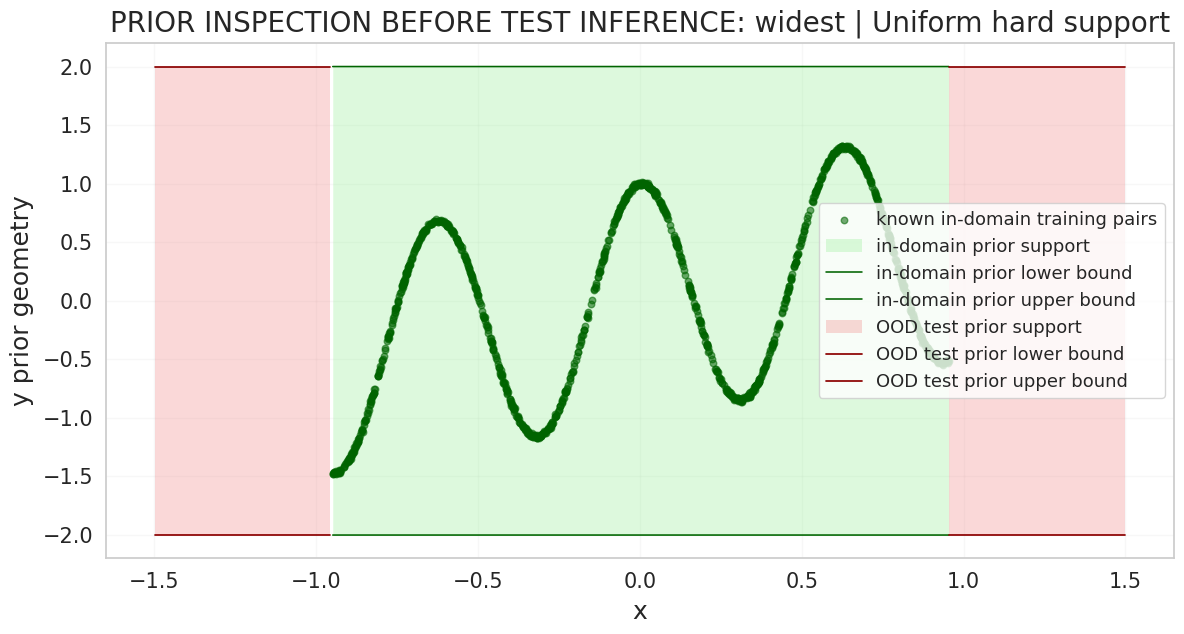

In [ ]:
# Evaluation-prior choice is independent of the prior family used during transport training.
# If GP priors were not needed during training, build them lazily here, AFTER transport training and
# after the baseline GP has been fitted. This keeps evaluation-only GP experiments out of training.
EVALUATE_WITH_GP_PRIORS = gp_priors_enabled_for_evaluation(CFG)
if EVALUATE_WITH_GP_PRIORS:
    if gp_prior_sampler is None:
        gp_prior_sampler = make_gp_prior_sampler(gp, CFG)

    if CFG.gp_prior_representation == "covariance_cloud" and gp_covariance_prior is None:
        print(
            "\n--- building evaluation-only pointwise GP-kernel-weighted Gaussian prior clouds "
            f"with {CFG.gp_prior_hyperparameter_source.upper()} hyperparameters ---"
        )
        gp_covariance_prior = build_gp_covariance_prior_cloud(
            gp_prior_sampler, X_train, Y_train, X_test, CFG
        )
    elif CFG.gp_prior_representation == "function_samples" and gp_prior_bank is None:
        print(
            "\n--- sampling evaluation-only coherent GP prior functions "
            f"with {CFG.gp_prior_hyperparameter_source.upper()} hyperparameters ---"
        )
        gp_prior_bank = sample_gp_function_prior_bank(gp_prior_sampler, X_train, X_test, CFG)

    if CFG.gp_prior_representation == "covariance_cloud":
        EVAL_MODE = "gp_covariance_cloud"
        if gp_covariance_prior is None:
            raise RuntimeError("GP covariance-cloud evaluation requires gp_covariance_prior.")
        print(
            f"\nSelected evaluation prior mode: {EVAL_MODE} | pointwise weighted Gaussian cloud | "
            f"eval particles={CFG.eval_particles}"
        )
        print(
            "The fresh UNFITTED GP contributes only its kernel hyperparameters as similarity weights; "
            "training y values determine local mean/variance. No Cholesky factorisation, function "
            "sampling, output noisification, or prior averaging is used."
        )
        plot_gp_covariance_prior_cloud(
            X_train, Y_train, X_test, gp_covariance_prior,
            out / f"evaluation_prior_ranges_{EVAL_MODE}.pdf", CFG,
        )
    else:
        EVAL_MODE = "gp_function_samples"
        if gp_prior_bank is None:
            raise RuntimeError("GP-function evaluation requires gp_prior_bank.")
        print(
            f"\nSelected evaluation prior mode: {EVAL_MODE} | "
            f"K={CFG.gp_prior_eval_samples} coherent GP functions | "
            f"particle noise std={CFG.gp_prior_particle_noise_std:.4f}"
        )
        print(
            "These cached prior functions were sampled from a fresh UNFITTED GP carrying the "
            f"{CFG.gp_prior_hyperparameter_source.upper()} kernel hyperparameters."
        )
        plot_gp_function_prior_bank(
            X_train, Y_train, X_test, gp_prior_bank,
            out / f"evaluation_prior_ranges_{EVAL_MODE}.pdf", CFG,
        )
else:
    # Historical post-training interval-prior experiments are preserved unchanged below.
    EVAL_MODE = CFG.evaluation_prior_mode
    # EVAL_MODE = "train_y_range"

    # Examples -- all available immediately after training:
    # EVAL_MODE = "cheating"               # oracle upper benchmark
    # EVAL_MODE = "widest"                 # fixed U(CFG.prior_min, CFG.prior_max)
    # EVAL_MODE = "nearest_training"        # existing kNN min/max envelope
    # EVAL_MODE = "gp_variance_matched"     # fitted-GP mean; uniform has matched variance
    # EVAL_MODE = "gp_95"                   # fitted-GP predictive 95%-style bounds
    # EVAL_MODE = "kernel_support"          # GP-like fallback without fitting/using a GP
    # EVAL_MODE = "nearest_distance"        # nearest y + width grows with x-distance
    # EVAL_MODE = "kernel_local_variance"   # local kernel mean/std + OOD widening
    # EVAL_MODE = "local_linear"            # local linear extrapolation + residual/OOD width
    # EVAL_MODE = "conformal_kernel"        # split-conformal-style fixed residual width
    # EVAL_MODE = "kernel_conformal"        # conformal width + support-aware OOD widening
    # EVAL_MODE = "train_y_range"           # simplest global observed-y envelope
    # EVAL_MODE = "nearest_y_fixed"         # nearest y + one fixed width
    # EVAL_MODE = "knn_quantile"            # robust local y quantile envelope
    # EVAL_MODE = "knn_range_distance"      # kNN range + explicit distance inflation
    # EVAL_MODE = "nearest_posterior"       # closest achieved posterior; sequential OOD propagation

    print_evaluation_prior_catalog()

    _test_oracle = Y_test if EVAL_MODE == "cheating" else None
    if EVAL_MODE == "nearest_posterior":
        # Dynamic empirical-cloud mode: before any test prediction, preview what each OOD point would
        # inherit from the FIXED training replay buffer. Later actual priors can change because newly
        # predicted OOD posterior clouds are inserted after every propagation batch.
        test_prior_low, test_prior_high, _preview_mean, _preview_source_x = (
            nearest_posterior_prior_preview_np(X_test, posterior_replay_buffer, CFG)
        )
    else:
        test_prior_low, test_prior_high = evaluation_prior_bounds_np(
            X_test, X_train, Y_train, scaling, CFG,
            mode=EVAL_MODE,
            y_query_oracle=_test_oracle,
            gp_model=gp,                 # reused only by gp_* modes; NEVER refit here
            eval_cfg=EVAL_PRIOR_CFG,
        )

    # In-domain/train diagnostics stay on the widest prior, exactly as in the historical cell.
    train_prior_low, train_prior_high = evaluation_prior_bounds_np(
        X_train, X_train, Y_train, scaling, CFG,
        mode="widest",
        gp_model=gp,
        eval_cfg=EVAL_PRIOR_CFG,
    )

    print(f"\nSelected evaluation prior mode: {EVAL_MODE} | particle prior family: {CFG.base_prior_distribution}")
    print("In-domain/train prior statistics: " + _prior_bounds_summary(train_prior_low, train_prior_high))
    if EVAL_MODE == "nearest_posterior":
        print(
            "OOD initial nearest-posterior preview: "
            + _prior_bounds_summary(test_prior_low, test_prior_high)
        )
        print(
            f"Training replay buffer: {len(posterior_replay_buffer)}/"
            f"{posterior_replay_buffer.capacity} stored (x, posterior-cloud) pairs"
        )
        print(
            "NOTE: these are the PRE-INFERENCE nearest training-buffer clouds. "
            "Actual later OOD priors update sequentially after each propagation batch."
        )
        plot_nearest_posterior_prior_preview(
            X_train, Y_train, X_test, posterior_replay_buffer,
            out / f"evaluation_prior_ranges_{EVAL_MODE}.pdf", CFG,
        )
    else:
        print("OOD test prior statistics: " + _prior_bounds_summary(test_prior_low, test_prior_high))
        plot_evaluation_prior_ranges_from_bounds(
            X_train, Y_train,
            train_prior_low, train_prior_high,
            X_test, test_prior_low, test_prior_high,
            EVAL_MODE,
            out / f"evaluation_prior_ranges_{EVAL_MODE}.pdf",
            CFG,
        )

DIRECT likelihood mode: deployment uses exactly ONE clean x observation.

--- same-split comparison; baselines were trained only once ---
MLP       train MSE=0.000265 test MSE=2.329263
GP        train MSE=0.000091 test MSE=2.566656
Transport train MSE=0.003388 test MSE=2.326270 | test ES=1.157011 cov95=0.243 | prior=widest mean-width=4.000 | likelihood observations=1


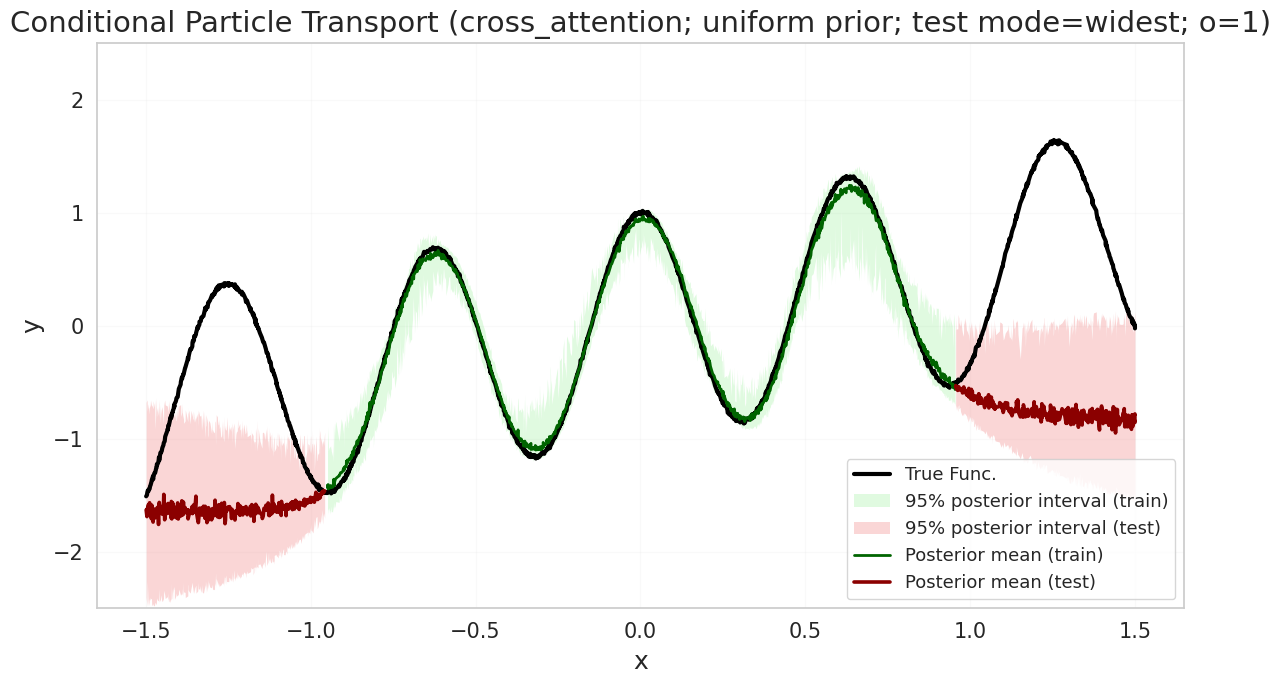

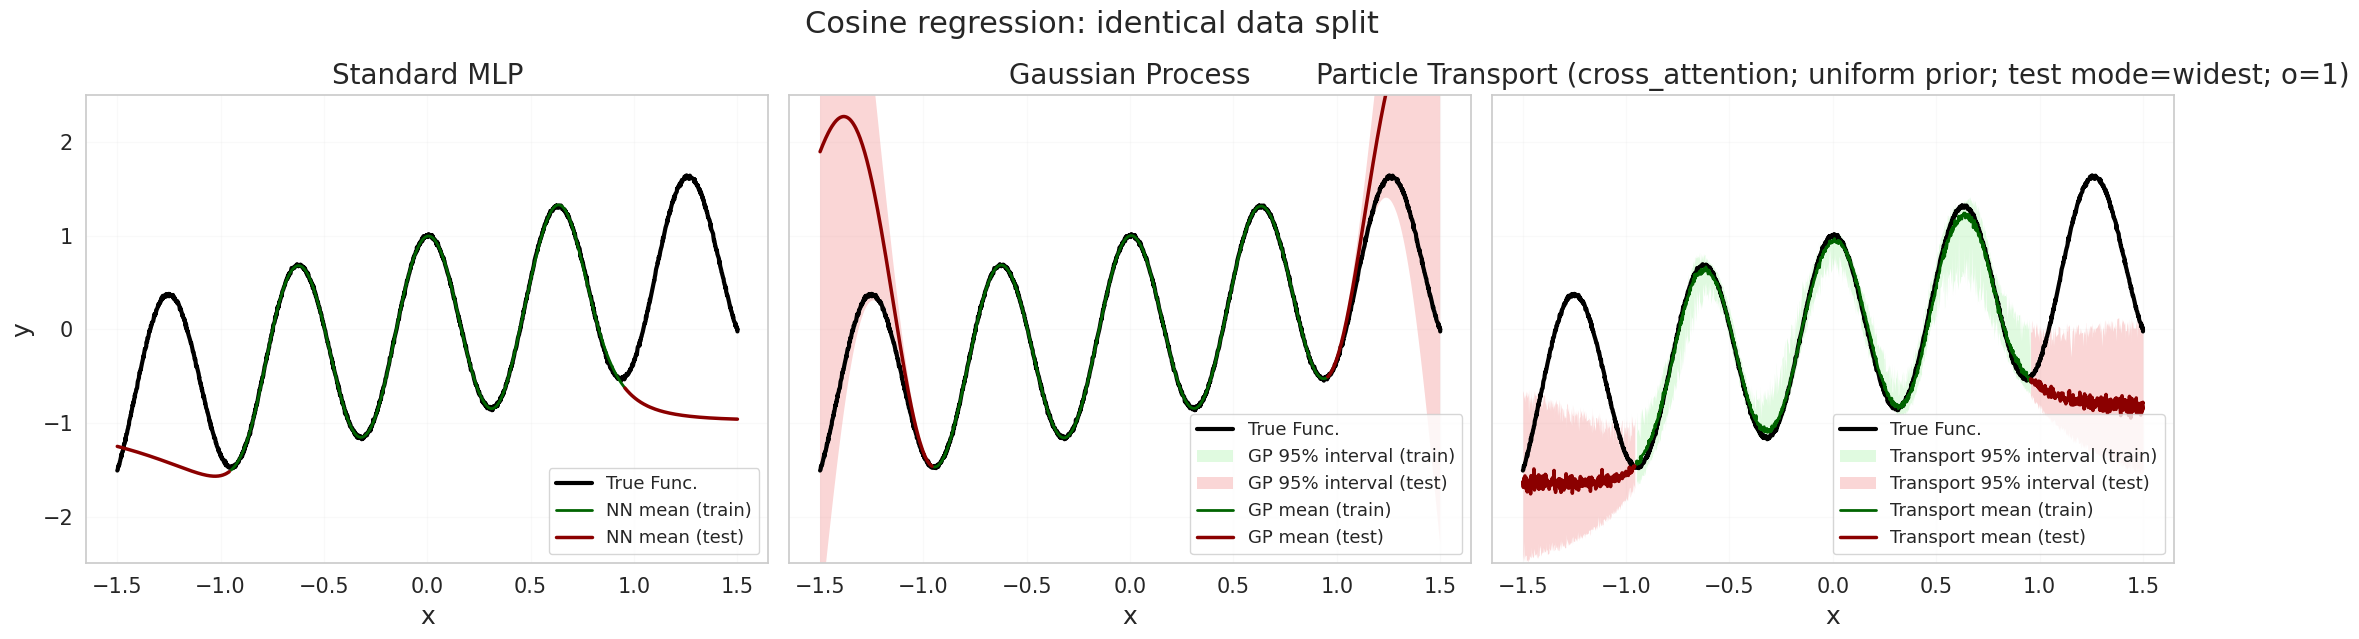

Saved evaluation outputs to /Users/ddrous/Projects/HiddenRep/limit_weight_space/plots/cosine_transport


In [ ]:
# DIRECT mode is intentionally fixed to ONE clean observed x, exactly like the attached
# historical cosine code. There is no likelihood Transformer and no deployment prefix.
# TRANSFORMER mode keeps the configurable deployment observation count.
if CFG.likelihood_conditioning_mode == "direct":
    DEPLOYMENT_OBSERVATIONS = 1
    print("DIRECT likelihood mode: deployment uses exactly ONE clean x observation.")
else:
    DEPLOYMENT_OBSERVATIONS = CFG.test_observations_per_step
    # DEPLOYMENT_OBSERVATIONS = 1
    # DEPLOYMENT_OBSERVATIONS = 3
    # DEPLOYMENT_OBSERVATIONS = CFG.max_observations_per_step

if EVALUATE_WITH_GP_PRIORS:
    if CFG.gp_prior_representation == "covariance_cloud":
        tr_train = predict_transport_gp_covariance_cloud(
            transport, X_train, gp_covariance_prior.train_eval_cloud, CFG,
            num_observations=DEPLOYMENT_OBSERVATIONS,
        )
        tr_test = predict_transport_gp_covariance_cloud(
            transport, X_test, gp_covariance_prior.test_eval_cloud, CFG,
            num_observations=DEPLOYMENT_OBSERVATIONS,
        )
    else:
        # Historical v2 evaluation: K sampled prior functions, one posterior each, then averaging.
        tr_train = predict_transport_gp_function_priors(
            transport, X_train, gp_prior_bank.train_values, CFG,
            seed=CFG.seed + 30_001,
            num_prior_samples=CFG.gp_prior_eval_samples,
            num_observations=DEPLOYMENT_OBSERVATIONS,
        )
        tr_test = predict_transport_gp_function_priors(
            transport, X_test, gp_prior_bank.test_values, CFG,
            seed=CFG.seed + 30_002,
            num_prior_samples=CFG.gp_prior_eval_samples,
            num_observations=DEPLOYMENT_OBSERVATIONS,
        )
        for prior_index in range(CFG.gp_prior_plot_samples):
            one_train = select_gp_function_prior_prediction(tr_train, prior_index, CFG)
            one_test = select_gp_function_prior_prediction(tr_test, prior_index, CFG)
            plot_gp_function_prior_posterior(
                X_train, Y_train, X_test, Y_test, one_train, one_test, prior_index,
                out / f"transport_gp_prior_sample_{prior_index + 1:02d}.pdf", CFG,
            )
else:
    # Historical evaluation path retained unchanged.
    tr_train = predict_transport_from_bounds(
        transport, X_train, train_prior_low, train_prior_high, CFG,
        seed=CFG.seed + 30_001,
        prior_mode="widest",
        num_observations=DEPLOYMENT_OBSERVATIONS,
    )

    if EVAL_MODE == "nearest_posterior":
        tr_test = predict_transport_nearest_posterior(
            transport,
            X_test,
            X_train,
            posterior_replay_buffer,
            CFG,
            seed=CFG.seed + 30_002,
            propagation_batch_size=EVAL_PRIOR_CFG.nearest_posterior_deployment_batch_size,
            num_observations=DEPLOYMENT_OBSERVATIONS,
        )
    else:
        tr_test = predict_transport_from_bounds(
            transport, X_test, test_prior_low, test_prior_high, CFG,
            seed=CFG.seed + 30_002,
            prior_mode=EVAL_MODE,
            num_observations=DEPLOYMENT_OBSERVATIONS,
        )

tr_train_metrics = evaluate_transport(tr_train, Y_train)
tr_test_metrics = evaluate_transport(tr_test, Y_test)

metrics = {
    "particle_transport": {"train": tr_train_metrics, "test": tr_test_metrics},
    **baseline_metrics,
    "evaluation_prior_mode": EVAL_MODE,
    "base_prior_distribution": CFG.base_prior_distribution,
    "use_gp_function_priors": bool(CFG.use_gp_function_priors),
    "use_gp_priors_for_training": bool(gp_priors_enabled_for_training(CFG)),
    "use_gp_priors_for_evaluation": bool(EVALUATE_WITH_GP_PRIORS),
    "training_prior_mode": (
        f"gp_{CFG.gp_prior_representation}" if gp_priors_enabled_for_training(CFG)
        else CFG.base_prior_distribution
    ),
    "gp_prior_hyperparameter_source": (
        CFG.gp_prior_hyperparameter_source if (gp_priors_enabled_for_training(CFG) or EVALUATE_WITH_GP_PRIORS) else None
    ),
    "gp_prior_representation": (CFG.gp_prior_representation if (gp_priors_enabled_for_training(CFG) or EVALUATE_WITH_GP_PRIORS) else None),
    "gp_prior_covariance_rank": None,  # retained metric key; weighted clouds have no factor rank
    "gp_prior_covariance_trace_fraction_captured": None,
    "gp_prior_weighted_train_mean_std": (
        None if gp_covariance_prior is None else float(np.mean(gp_covariance_prior.train_std))
    ),
    "gp_prior_weighted_test_mean_std": (
        None if gp_covariance_prior is None else float(np.mean(gp_covariance_prior.test_std))
    ),
    "gp_prior_eval_samples": (
        int(CFG.gp_prior_eval_samples)
        if EVALUATE_WITH_GP_PRIORS and CFG.gp_prior_representation == "function_samples" else None
    ),
    "gp_prior_particle_noise_std": (
        float(CFG.gp_prior_particle_noise_std)
        if EVALUATE_WITH_GP_PRIORS and CFG.gp_prior_representation == "function_samples" else None
    ),
    "likelihood_conditioning_mode": CFG.likelihood_conditioning_mode,
    "deployment_observations": int(DEPLOYMENT_OBSERVATIONS),
    "nearest_posterior_deployment_batch_size": (
        int(EVAL_PRIOR_CFG.nearest_posterior_deployment_batch_size)
        if (not EVALUATE_WITH_GP_PRIORS and EVAL_MODE == "nearest_posterior") else None
    ),
    "scaling": asdict(scaling),
    "config": asdict(CFG),
}

print("\n--- same-split comparison; baselines were trained only once ---")
print(f"MLP       train MSE={metrics['mlp']['train_mse']:.6f} test MSE={metrics['mlp']['test_mse']:.6f}")
print(f"GP        train MSE={metrics['gp']['train_mse']:.6f} test MSE={metrics['gp']['test_mse']:.6f}")
print(
    f"Transport train MSE={tr_train_metrics['mse']:.6f} test MSE={tr_test_metrics['mse']:.6f} | "
    f"test ES={tr_test_metrics['energy_score']:.6f} cov95={tr_test_metrics['coverage_95']:.3f} | "
    f"prior={EVAL_MODE} mean-width={tr_test_metrics['mean_prior_width']:.3f} | "
    f"likelihood observations={DEPLOYMENT_OBSERVATIONS}"
)
if EVALUATE_WITH_GP_PRIORS:
    if CFG.gp_prior_representation == "covariance_cloud":
        print(
            "GP covariance cloud uses kernel-weighted training-y Gaussian moments with "
            f"{CFG.gp_prior_hyperparameter_source.upper()} GP hyperparameters; "
            "one sampled prior cloud and one posterior cloud are used at inference."
        )
    else:
        print(
            f"GP function-sample average uses K={CFG.gp_prior_eval_samples} coherent prior draws with "
            f"{CFG.gp_prior_hyperparameter_source.upper()} GP hyperparameters; "
            f"saved {CFG.gp_prior_plot_samples} individual prior->posterior plots."
        )
elif EVAL_MODE == "nearest_posterior":
    print(
        "Nearest-posterior propagation: "
        f"batch_size={EVAL_PRIOR_CFG.nearest_posterior_deployment_batch_size} | "
        "batch_size=1 is exact point-by-point outward continuation."
    )

# Mode-specific filenames preserve previous evaluation experiments instead of overwriting them.
with (out / f"metrics_{EVAL_MODE}.json").open("w") as f:
    json.dump(metrics, f, indent=2)

plot_transport(
    X_train, Y_train, X_test, Y_test, tr_train, tr_test,
    out / f"transport_predictions_uncertainty_{EVAL_MODE}.pdf", CFG,
)
plot_comparison(
    X_train, Y_train, X_test, Y_test,
    nn_train, nn_test, gp_train, gp_train_std, gp_test, gp_test_std,
    tr_train, tr_test,
    out / f"final_comparison_{EVAL_MODE}.pdf", CFG,
)
print(f"Saved evaluation outputs to {out.resolve()}")